# HW 4

Config stuff

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from matplotlib import pyplot as plt
from numpy.typing import NDArray
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

Make the seed 242...apparently `np.random.seed(242)` is not the new way to do it

In [2]:
seed = 242
rng = np.random.default_rng(seed)

## Problem 1

### (a): Compare random forest vs. OLS to estimate OSR^2 on bootstrapped data

We want to see the following:

1. Bias and variance of empirical estimator $\hat{\theta}$
2. 95% confidence interval for population test $\theta^{*}$
3. Histogram of bootstrapped OSR^2 for OLS and RF
4. Histogram of difference between OSR^2 for OLS and RF. 

> I had written the code and asked Amp (by Sourcegrpah, AI tool) to modularize everything so I could run part (b) by just calling a higher $N$ value
> 
> Below is all the modularized functions, but based on original code

#### Data Generation

In [3]:
def generate_data(N: int, rng: np.random.Generator) -> tuple[NDArray, NDArray]:
    """
    Generate synthetic data: X ~ N(0,1), error ~ N(0,1), y = 1 + 2.5*x + error

    Args:
        N: Sample size
        rng: Random number generator

    Returns:
        x, y arrays
    """
    x = rng.normal(0, 1, N)
    error = rng.normal(0, 1, N)
    y = 1 + 2.5 * x + error
    return x, y


def train_test_split_data(
    x: NDArray, y: NDArray, test_size: float = 0.2, seed: int = 242
) -> tuple[NDArray, NDArray, NDArray, NDArray]:
    """Split data into train/test sets."""
    return train_test_split(x, y, test_size=test_size, random_state=seed)

#### Bootstrapping

Ran into a fun error here, where providing the seed inside the `resample` call will result in the same bootstrap generation for each `B` iteration, so you gotta set `np.random.seed` within this function call

In [4]:
def create_test_bootstraps(
    X_test: NDArray, y_test: NDArray, B: int = 2000, seed: int = 242
) -> tuple[list[NDArray], list[NDArray]]:
    """
    Create B bootstrap samples from the test set.

    Args:
        X_test: Test features
        y_test: Test targets
        B: Number of bootstrap samples
        seed: Random seed (sets numpy RNG globally for this operation)

    Returns:
        Lists of bootstrapped X and y test sets
    """
    # Seed numpy's global RNG so resamples are independent but reproducible
    np.random.seed(seed)

    X_test_bootstraps = []
    y_test_bootstraps = []

    for i in range(B):
        X_resampled, y_resampled = resample(
            X_test, y_test, replace=True, n_samples=len(X_test)
        )
        X_test_bootstraps.append(X_resampled)
        y_test_bootstraps.append(y_resampled)

    return X_test_bootstraps, y_test_bootstraps

#### Model Fitting

In [5]:
def fit_ols_model(X_train: NDArray, y_train: NDArray) -> LinearRegression:
    """Fit OLS linear regression model."""
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


def fit_rf_model(
    X_train: NDArray, y_train: NDArray, random_state: int = 242
) -> RandomForestRegressor:
    """Fit Random Forest regression model."""
    model = RandomForestRegressor(random_state=random_state)
    model.fit(X_train, y_train)
    return model

#### OSR^2

In [6]:
def compute_empirical_osr2(model, X_test: NDArray, y_test: NDArray) -> float:
    """
    Compute out-of-sample R^2 on original test set.

    Args:
        model: Fitted sklearn model
        X_test: Test features (1D array)
        y_test: Test targets

    Returns:
        R^2 score
    """
    X_reshaped = X_test.reshape(-1, 1)
    y_pred = model.predict(X_reshaped)
    return r2_score(y_test, y_pred)


def compute_bootstrapped_osr2(
    model, X_test_bootstraps: list[NDArray], y_test_bootstraps: list[NDArray]
) -> list[float]:
    """
    Compute out-of-sample R^2 on each bootstrap test sample.

    Args:
        model: Fitted sklearn model
        X_test_bootstraps: List of bootstrapped test features
        y_test_bootstraps: List of bootstrapped test targets

    Returns:
        List of R^2 scores for each bootstrap
    """
    r2_scores = []

    for X_boot, y_boot in zip(X_test_bootstraps, y_test_bootstraps):
        X_reshaped = X_boot.reshape(-1, 1)
        y_pred = model.predict(X_reshaped)
        r2 = r2_score(y_boot, y_pred)
        r2_scores.append(r2)

    return r2_scores

#### Bias / Variance / Confidence Intervals

In [7]:
def compute_bias_variance_ci(
    bootstrapped_scores: list[float], empirical_score: float, ci: float = 0.05
) -> dict:
    """
    Compute bias, variance, and confidence interval for a metric.

    Args:
        bootstrapped_scores: List of scores from bootstrap samples
        empirical_score: The empirical score on original test set
        ci: Significance level (default 0.05 for 95% CI)

    Returns:
        Dictionary with bias, variance, and CI bounds
    """
    bootstrap_mean = np.mean(bootstrapped_scores)

    bias = bootstrap_mean - empirical_score
    variance = (1 / len(bootstrapped_scores)) * sum(
        [(score - empirical_score) ** 2 for score in bootstrapped_scores]
    )

    lower_bound = np.quantile(bootstrapped_scores, ci / 2)
    upper_bound = np.quantile(bootstrapped_scores, 1 - ci / 2)

    return {
        "bias": bias,
        "variance": variance,
        "ci_lower": lower_bound,
        "ci_upper": upper_bound,
    }


def compute_difference_ci(
    bootstrapped_scores_1: list[float],
    bootstrapped_scores_2: list[float],
    ci: float = 0.05,
) -> dict:
    """
    Compute 95% bootstrap CI for the difference between two metrics.

    Args:
        bootstrapped_scores_1: List of bootstrap scores (e.g., OLS)
        bootstrapped_scores_2: List of bootstrap scores (e.g., RF)
        ci: Significance level (default 0.05 for 95% CI)

    Returns:
        Dictionary with difference mean and CI bounds
    """
    diff = np.array(bootstrapped_scores_1) - np.array(bootstrapped_scores_2)

    mean_diff = np.mean(diff)
    lower_bound = np.quantile(diff, ci / 2)
    upper_bound = np.quantile(diff, 1 - ci / 2)

    return {
        "mean_diff": mean_diff,
        "ci_lower": lower_bound,
        "ci_upper": upper_bound,
    }

#### Print Statements

In [8]:
def report_empirical_scores(ols_r2: float, rf_r2: float) -> None:
    """Print out-of-sample R^2 scores on original test set."""
    print("=" * 70)
    print("EMPIRICAL OSR^2 (on original test set)")
    print("=" * 70)
    print(f"OLS:     {ols_r2*100:.2f}%")
    print(f"RF:      {rf_r2*100:.2f}%")
    print()


def report_statistics(model_name: str, stats: dict) -> None:
    """Print bias, variance, and CI for a model."""
    print(f"{model_name} OSR^2:")
    print(f"  Bias:        {stats['bias']:.4f}")
    print(f"  Variance:    {stats['variance']:.4f}")
    print(f"  95% CI:      ({stats['ci_lower']:.4f}, {stats['ci_upper']:.4f})")
    print()


def report_all_statistics(ols_stats: dict, rf_stats: dict) -> None:
    """Print statistics for both models."""
    print("=" * 70)
    print("BOOTSTRAP STATISTICS")
    print("=" * 70)
    report_statistics("OLS", ols_stats)
    report_statistics("RF", rf_stats)


def report_difference_ci(diff_stats: dict) -> None:
    """Print 95% CI for the difference (OLS - RF)."""
    print("=" * 70)
    print("DIFFERENCE (OLS - RF) 95% BOOTSTRAP CI")
    print("=" * 70)
    print(f"Mean Difference: {diff_stats['mean_diff']:.4f}")
    print(
        f"95% CI:          ({diff_stats['ci_lower']:.4f}, {diff_stats['ci_upper']:.4f})"
    )
    print()

#### Plots

In [9]:
def plot_bootstrap_distributions(
    ols_bootstrapped_r2: list[float],
    rf_bootstrapped_r2: list[float],
) -> None:
    """Plot histograms of bootstrapped OSR^2 for both models."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(ols_bootstrapped_r2, bins=30, alpha=0.7, edgecolor="black")
    axes[0].set_title("OLS Bootstrapped OSR^2")
    axes[0].set_xlabel("R^2 Score")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(rf_bootstrapped_r2, bins=30, alpha=0.7, edgecolor="black")
    axes[1].set_title("RF Bootstrapped OSR^2")
    axes[1].set_xlabel("R^2 Score")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


def plot_difference_distribution(
    ols_bootstrapped_r2: list[float],
    rf_bootstrapped_r2: list[float],
) -> None:
    """Plot histogram of OSR^2 difference (OLS - RF)."""
    diff = np.array(ols_bootstrapped_r2) - np.array(rf_bootstrapped_r2)

    plt.figure(figsize=(8, 4))
    plt.hist(diff, bins=30, alpha=0.7, edgecolor="black")
    plt.title("OSR^2 Difference (OLS - RF)")
    plt.xlabel("Difference in R^2 Score")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

#### Orchestrator function

This is what we're gonna call with `N=300` for part (a), and `N=2000` for part (b)

In [10]:
def run_analysis(N: int, B: int = 2000, seed: int = 242, verbose: bool = True) -> dict:
    """
    Run complete Problem 1 analysis for a given sample size N.

    Args:
        N: Sample size for data generation
        B: Number of bootstrap samples
        seed: Random seed
        verbose: Whether to print results

    Returns:
        Dictionary containing all results
    """

    # Data generation
    x, y = generate_data(N, rng)
    X_train, X_test, y_train, y_test = train_test_split_data(x, y, seed=seed)

    # Bootstrap test sets
    X_test_bootstraps, y_test_bootstraps = create_test_bootstraps(
        X_test, y_test, B=B, seed=seed
    )

    # Fit models
    ols_model = fit_ols_model(X_train.reshape(-1, 1), y_train)
    rf_model = fit_rf_model(X_train.reshape(-1, 1), y_train, random_state=seed)

    # Empirical scores (on original test set)
    ols_empirical_r2 = compute_empirical_osr2(ols_model, X_test, y_test)
    rf_empirical_r2 = compute_empirical_osr2(rf_model, X_test, y_test)

    # Bootstrapped scores
    ols_bootstrapped_r2 = compute_bootstrapped_osr2(
        ols_model, X_test_bootstraps, y_test_bootstraps
    )
    rf_bootstrapped_r2 = compute_bootstrapped_osr2(
        rf_model, X_test_bootstraps, y_test_bootstraps
    )

    # Statistics
    ols_stats = compute_bias_variance_ci(ols_bootstrapped_r2, ols_empirical_r2)
    rf_stats = compute_bias_variance_ci(rf_bootstrapped_r2, rf_empirical_r2)
    diff_stats = compute_difference_ci(ols_bootstrapped_r2, rf_bootstrapped_r2)

    if verbose:
        report_empirical_scores(ols_empirical_r2, rf_empirical_r2)
        report_all_statistics(ols_stats, rf_stats)
        report_difference_ci(diff_stats)

    return {
        "N": N,
        "B": B,
        "ols_empirical_r2": ols_empirical_r2,
        "rf_empirical_r2": rf_empirical_r2,
        "ols_bootstrapped_r2": ols_bootstrapped_r2,
        "rf_bootstrapped_r2": rf_bootstrapped_r2,
        "ols_stats": ols_stats,
        "rf_stats": rf_stats,
        "diff_stats": diff_stats,
        "ols_model": ols_model,
        "rf_model": rf_model,
    }

### (a): Solution for `N=300`

In [11]:
results_300 = run_analysis(N=300)

EMPIRICAL OSR^2 (on original test set)
OLS:     86.52%
RF:      80.38%

BOOTSTRAP STATISTICS
OLS OSR^2:
  Bias:        -0.0068
  Variance:    0.0011
  95% CI:      (0.7865, 0.9143)

RF OSR^2:
  Bias:        -0.0116
  Variance:    0.0026
  95% CI:      (0.6809, 0.8736)

DIFFERENCE (OLS - RF) 95% BOOTSTRAP CI
Mean Difference: 0.0662
95% CI:          (0.0049, 0.1441)



The 95% CI for the difference is (0.0049, 0.1441)

The interpretation is that OLS performs about 0.4% to 1.4% better on fitting unseen data than RF for this dataset.

Since 0 is not in this interval, this means that we are 95% sure that the difference between the OLS and RF OSR^2 is non-zero, or there is some difference between OLS and RF to fit this particular dataset

Additionally, since the interval is positive, the OLS is statistically significantly better than RF. 

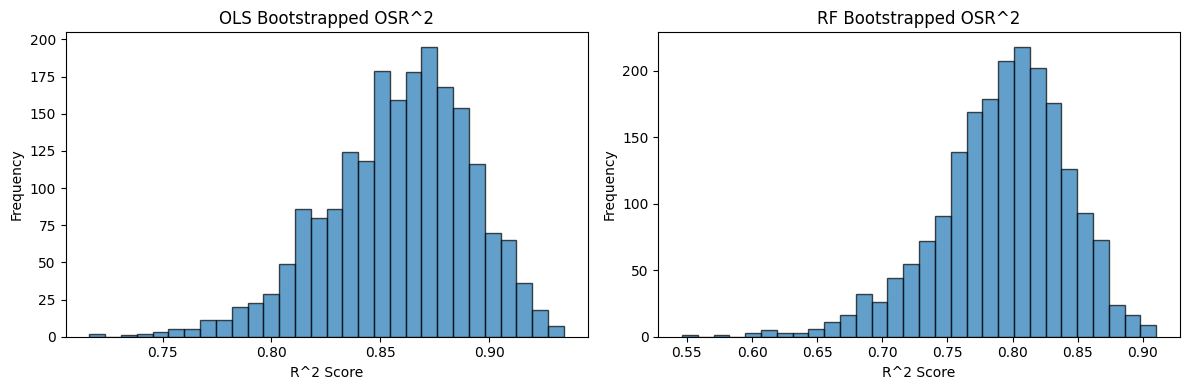

In [12]:
plot_bootstrap_distributions(
    results_300["ols_bootstrapped_r2"], results_300["rf_bootstrapped_r2"]
)

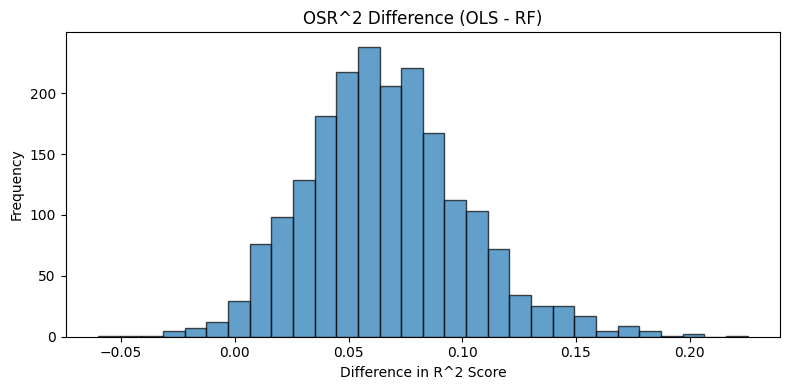

In [13]:
plot_difference_distribution(
    results_300["ols_bootstrapped_r2"], results_300["rf_bootstrapped_r2"]
)

### (b): Solution for `N=2000`

In [14]:
results_2000 = run_analysis(N=2000)

EMPIRICAL OSR^2 (on original test set)
OLS:     84.85%
RF:      79.88%

BOOTSTRAP STATISTICS
OLS OSR^2:
  Bias:        -0.0010
  Variance:    0.0002
  95% CI:      (0.8182, 0.8729)

RF OSR^2:
  Bias:        -0.0010
  Variance:    0.0003
  95% CI:      (0.7610, 0.8316)

DIFFERENCE (OLS - RF) 95% BOOTSTRAP CI
Mean Difference: 0.0496
95% CI:          (0.0278, 0.0714)



The 95% CI for the difference is (0.0278, 0.0714)

The interpretation is that OLS performs about 2% to 7% better on fitting unseen data than RF for this dataset.

Since 0 is not in the interval in either case, this means that we are 95% sure that the difference between the OLS and RF OSR^2 is non-zero, or there is some difference between OLS and RF to fit this particular dataset

Additionally, since the interval is positive, the OLS is statistically significantly better than RF. 


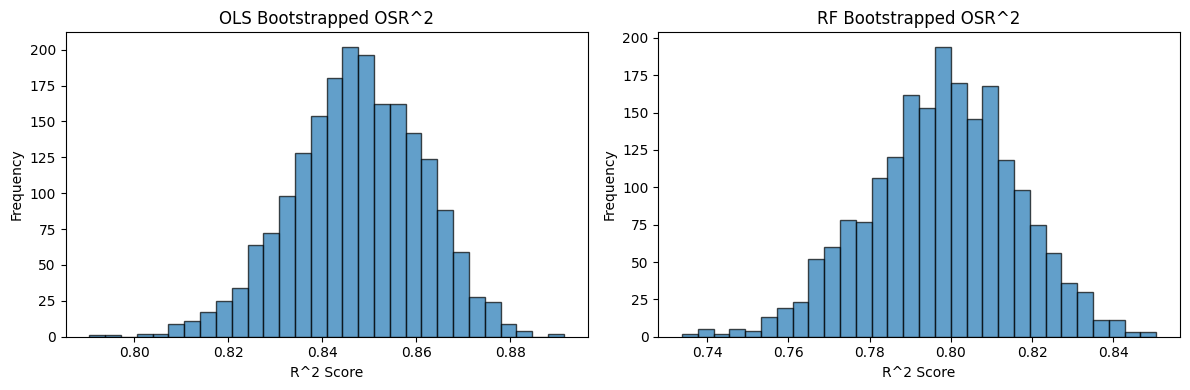

In [15]:
plot_bootstrap_distributions(
    results_2000["ols_bootstrapped_r2"], results_2000["rf_bootstrapped_r2"]
)


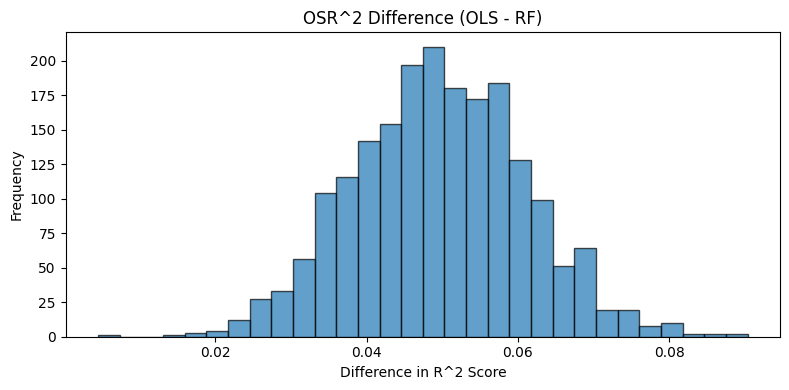

In [16]:
plot_difference_distribution(
    results_2000["ols_bootstrapped_r2"], results_2000["rf_bootstrapped_r2"]
)


## Problem 2

In [17]:
df = pd.read_csv("data/AirPassengers.csv")
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


### (a) Visualize and comment on trends

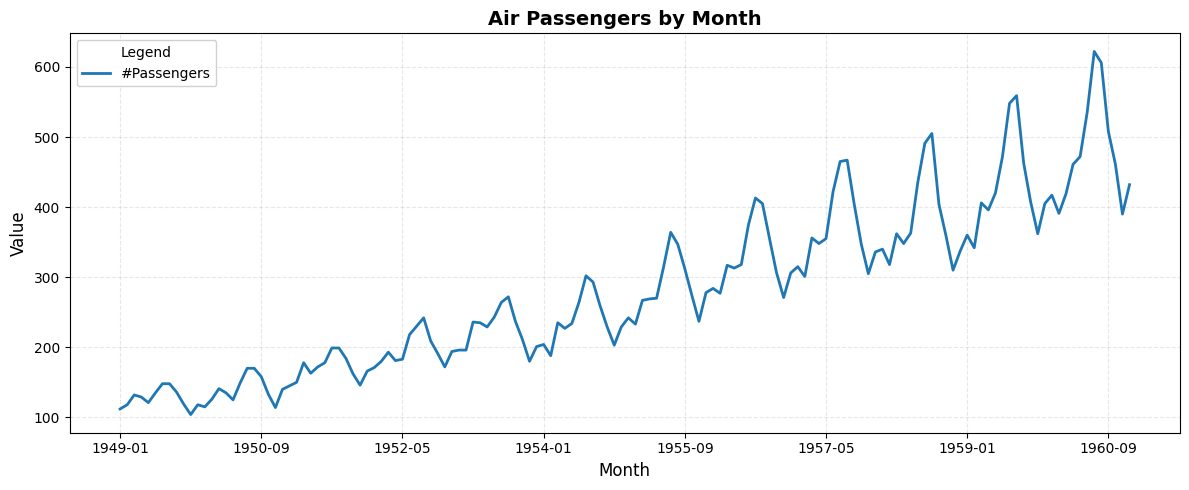

In [18]:
# from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots(figsize=(12, 5))
df.set_index("Month").plot(ax=ax, linewidth=2)

ax.set_title("Air Passengers by Month", fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(title="Legend", loc="best", framealpha=0.9)

plt.tight_layout()
plt.show()

**Trend**:

There is a trend in the upward direction. More air passengers, as month increases.

**Seasonality**:

There is a seasonality, with travel in general peaking during the winter months.

**Stationarity**:

The process is certainly not stationary, since the mean is increasing and the variance
depends on the time:

- **Mean**: clearly increasing as the months increase
- **Variance**: spread in the data increases as the months increase

### (b) Linear trend and AR(1)

Report the following:

- R-squared
- Test OSR^2
- Expected yearly change in the total number of international airline passengers
- Why is AR(1) not performing well?

#### Data pre-processing

1. Create the Month column
2. Create last month number of passengers column
3. Rename columns

In [19]:
df["Month"] = pd.to_datetime(df["Month"])
df.rename(columns={"#Passengers": "num_passengers", "Month": "month"}, inplace=True)

time_period = list(range(len(df)))
df.loc[:, ["time_period"]] = time_period
df.loc[:, "num_passengers_last_month"] = df["num_passengers"].shift(1)

df.head()

,month,num_passengers,time_period,num_passengers_last_month
0,1949-01-01,112,0,NaN
1,1949-02-01,118,1,112.0
2,1949-03-01,132,2,118.0
3,1949-04-01,129,3,132.0
4,1949-05-01,121,4,129.0


#### Train / test split

Using 1958, since this data is from 1949 to 1960, so let's see if we can predict the
last two years of data

In [20]:
def train_test_split_time_series(
    df: pd.DataFrame, year_threshold: int
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train = df[df.month.dt.year < year_threshold]
    test = df[df.month.dt.year >= year_threshold]
    return train, test


train, test = train_test_split_time_series(df, 1959)

print(len(train))
print(len(test))

120
24


#### Set the actuals to their own variable

In [21]:
train_actuals = train["num_passengers"]
test_actual = test["num_passengers"]

#### Write the plot function

In [22]:
def plot_fitted_vs_actual(y_actual, model, title="Fitted vs Actual"):
    """
    Plot actual vs fitted values from a statsmodels model.

    Args:
        y_actual: Actual time series values
        model: Fitted statsmodels result object
        title: Plot title
    """
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(y_actual, label="Actual", linewidth=2, color="black")
    ax.plot(model.fittedvalues, label="Fitted", linewidth=2, alpha=0.7, linestyle="--")

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="best", framealpha=0.9)

    plt.tight_layout()
    plt.show()


def plot_predicted_vs_actual(y_test, y_pred, title="Predicted vs Actual (Test Set)"):
    """
    Plot actual vs predicted values on test set.

    Args:
        y_test: Actual test values
        y_pred: Predicted values from model
        title: Plot title
    """
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(y_test, label="Actual", linewidth=2, color="black")
    ax.plot(y_pred, label="Predicted", linewidth=2, alpha=0.7, linestyle="--")

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="best", framealpha=0.9)

    plt.tight_layout()
    plt.show()


def plot_compare_predictions(
    y_test, y_pred_1, y_pred_2, title="Actuals vs. Two Predictions", labels=None
):
    """
    Plot actuals vs two sets of predictions

    Args:
        y_test: Actual test values
        y_pred_1: Predicted values from model_1
        y_pred_2: Predicted values from model_2
        title: Plot title
        labels: Tuple of labels for each chart
    """
    label_1, label_2 = labels if labels else ("Prediction 1", "Prediction 2")

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(y_test, label="Actual", linewidth=2, color="black")
    ax.plot(
        y_pred_1, label=label_1, linewidth=2, alpha=0.7, linestyle="--", color="blue"
    )
    ax.plot(
        y_pred_2, label=label_2, linewidth=2, alpha=0.7, linestyle="--", color="red"
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="best", framealpha=0.9)

    plt.tight_layout()
    plt.show()

#### OLS Model

In [23]:
lm = smf.ols(formula="num_passengers ~ time_period", data=train).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:         num_passengers   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     599.6
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           4.44e-48
Time:                        02:06:38   Log-Likelihood:                -607.85
No. Observations:                 120   AIC:                             1220.
Df Residuals:                     118   BIC:                             1225.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      97.4610      7.015     13.893      

In [24]:
test_pred = lm.predict(test["time_period"])
osr2_ols = r2_score(test_actual, test_pred)
print(f"Out of sample R-squared for OLS: {osr2_ols:.4f}")

Out of sample R-squared for OLS: -0.0030


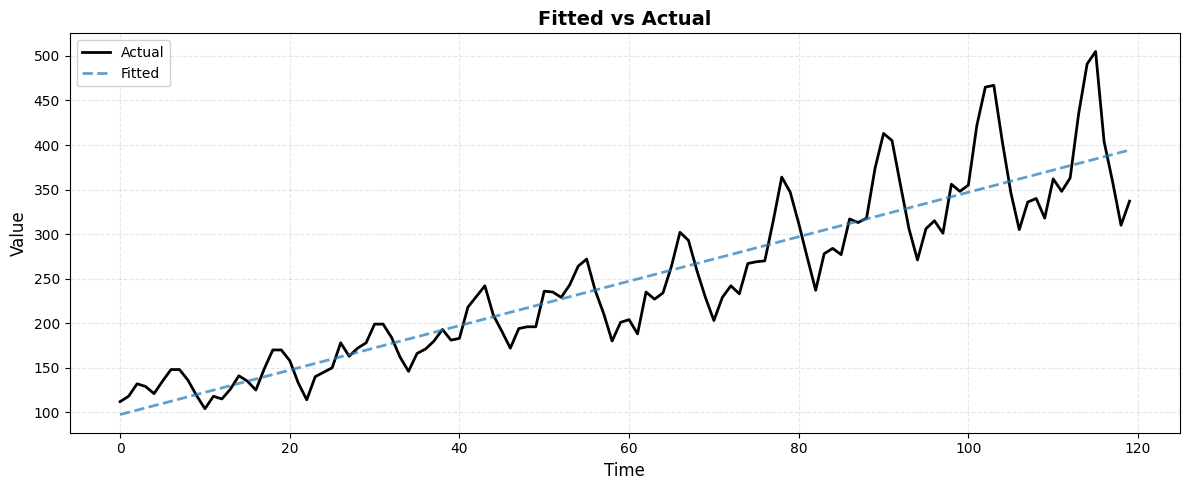

In [25]:
plot_fitted_vs_actual(train_actuals, lm)

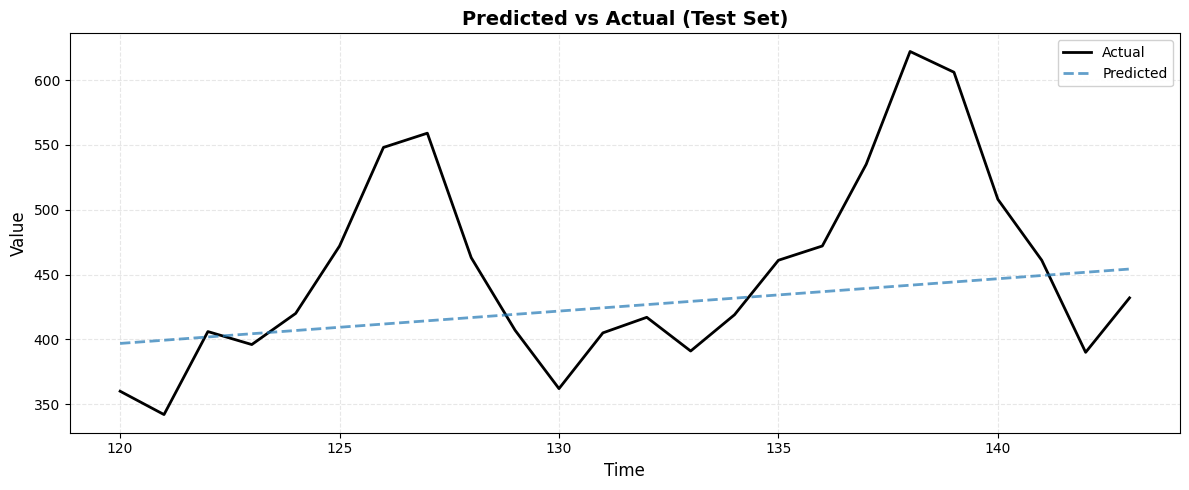

In [26]:
y_pred = lm.predict(test)
plot_predicted_vs_actual(test_actual, y_pred)

#### Fit AR(1) Model

In [27]:
ar_1 = smf.ols(formula="num_passengers ~ num_passengers_last_month", data=train).fit()
print(ar_1.summary())

                            OLS Regression Results                            
Dep. Variable:         num_passengers   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     1182.
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           5.46e-63
Time:                        02:06:39   Log-Likelihood:                -566.47
No. Observations:                 119   AIC:                             1137.
Df Residuals:                     117   BIC:                             1143.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [28]:
test_pred = ar_1.predict(test["num_passengers_last_month"])
osr2_ols = r2_score(test_actual, test_pred)
print(f"Out of sample R-squared for OLS: {osr2_ols:.2f}")

Out of sample R-squared for OLS: 0.52


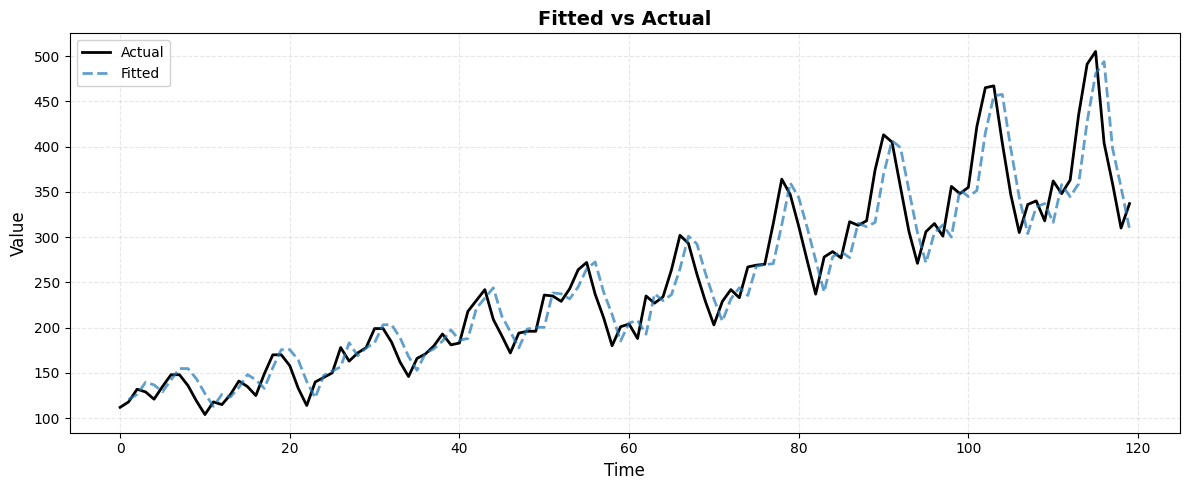

In [29]:
plot_fitted_vs_actual(train_actuals, ar_1)

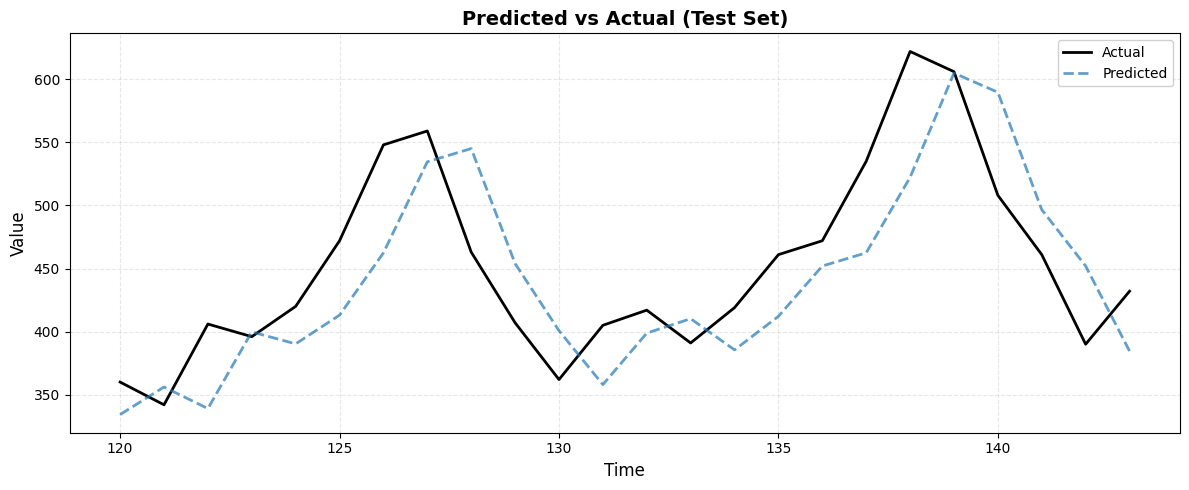

In [30]:
y_pred = ar_1.predict(test)
plot_predicted_vs_actual(test_actual, y_pred)

#### What is the expected yearly change of the total number of airline passengers? 

To answer this question for OLS, we can write a function that takes the coefficient, and just multiples it by 12 to get the implied effect for a year. 

For an AR(1) model, the coefficient won't be interpreted like that. We could look at the mean change by comparing the first vs. the last period – or find the average change per period, and scale that to yearly. We could also forecast ahead, and compute the implied trend.

In [31]:
def expected_yearly_change(model, data_frequency="monthly"):
    """
    Extract expected yearly change from OLS or AR(1) model.

    Args:
        model: Fitted statsmodels result object
        data_frequency: 'monthly' or 'yearly'

    Returns:
        Expected yearly change
    """
    if data_frequency == "monthly":
        scale = 12
    else:
        scale = 1

    # For OLS: coefficient on time trend
    if hasattr(model, "params") and "time" in model.params.index:
        coef = model.params["time"]
        yearly_change = coef * scale
        return yearly_change

    # For AR(1): look at mean level change by comparing first vs last periods
    fitted = model.fittedvalues
    if len(fitted) > 0:
        # Average change per period, scaled to yearly
        avg_change_per_period = (fitted.iloc[-1] - fitted.iloc[0]) / len(fitted)
        yearly_change = avg_change_per_period * scale
        return yearly_change

    return None


In [32]:
print(f"OLS Expected yearly change: {expected_yearly_change(lm, "monthly"):.2f}")
print(f"AR(1) Expected yearly change: {expected_yearly_change(ar_1, "monthly"):.2f}")

OLS Expected yearly change: 29.69
AR(1) Expected yearly change: 18.96


Here are the metrics for each model

| Metric | Linear Model | Autoregressive (1) | 
| -- | -- | -- |
| Training R-squared | 0.836 | 0.910 |
| Test OSR-squared | -0.003 | 0.52 | 
| Expected Yearly Change | 29.69 | 18.96 |

The results of the AR(1) aren't that useful because the process we're trying to model is not stationary. It's mean is generally increasing, and the overall variation in number of airline passengers is also increasing. The mathematical formulation of AR(1) relies on stationary data.

### (c) Feature Engineering

In [33]:
def plot_by_month(df, date_col="Month", value_col="Count"):
    """
    Plot data grouped by calendar month with trend lines (4x3 panel).

    Args:
        df: DataFrame with datetime column
        date_col: Name of datetime column
        value_col: Name of value column to plot
    """
    df_copy = df.copy()
    df_copy["MonthName"] = pd.to_datetime(df_copy[date_col]).dt.month_name()

    fig, axes = plt.subplots(4, 3, figsize=(15, 12))
    axes = axes.flatten()

    months = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ]

    for idx, month in enumerate(months):
        ax = axes[idx]
        month_data = df_copy[df_copy["MonthName"] == month]

        # Plot actual values as line
        x = np.arange(len(month_data))
        y = month_data[value_col].values
        ax.plot(x, y, linewidth=2, color="steelblue", label="Actual")

        # Fit and plot trend line
        if len(x) > 1:
            coeffs = np.polyfit(x, y, 1)
            trend = np.polyval(coeffs, x)
            ax.plot(x, trend, "r--", linewidth=2, label="Trend")

        ax.set_title(month, fontsize=12, fontweight="bold")
        ax.set_xlabel("Year Index", fontsize=10)
        ax.set_ylabel(value_col, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor("white")
        ax.legend(fontsize=9)

    fig.patch.set_facecolor("white")
    plt.tight_layout()
    plt.show()


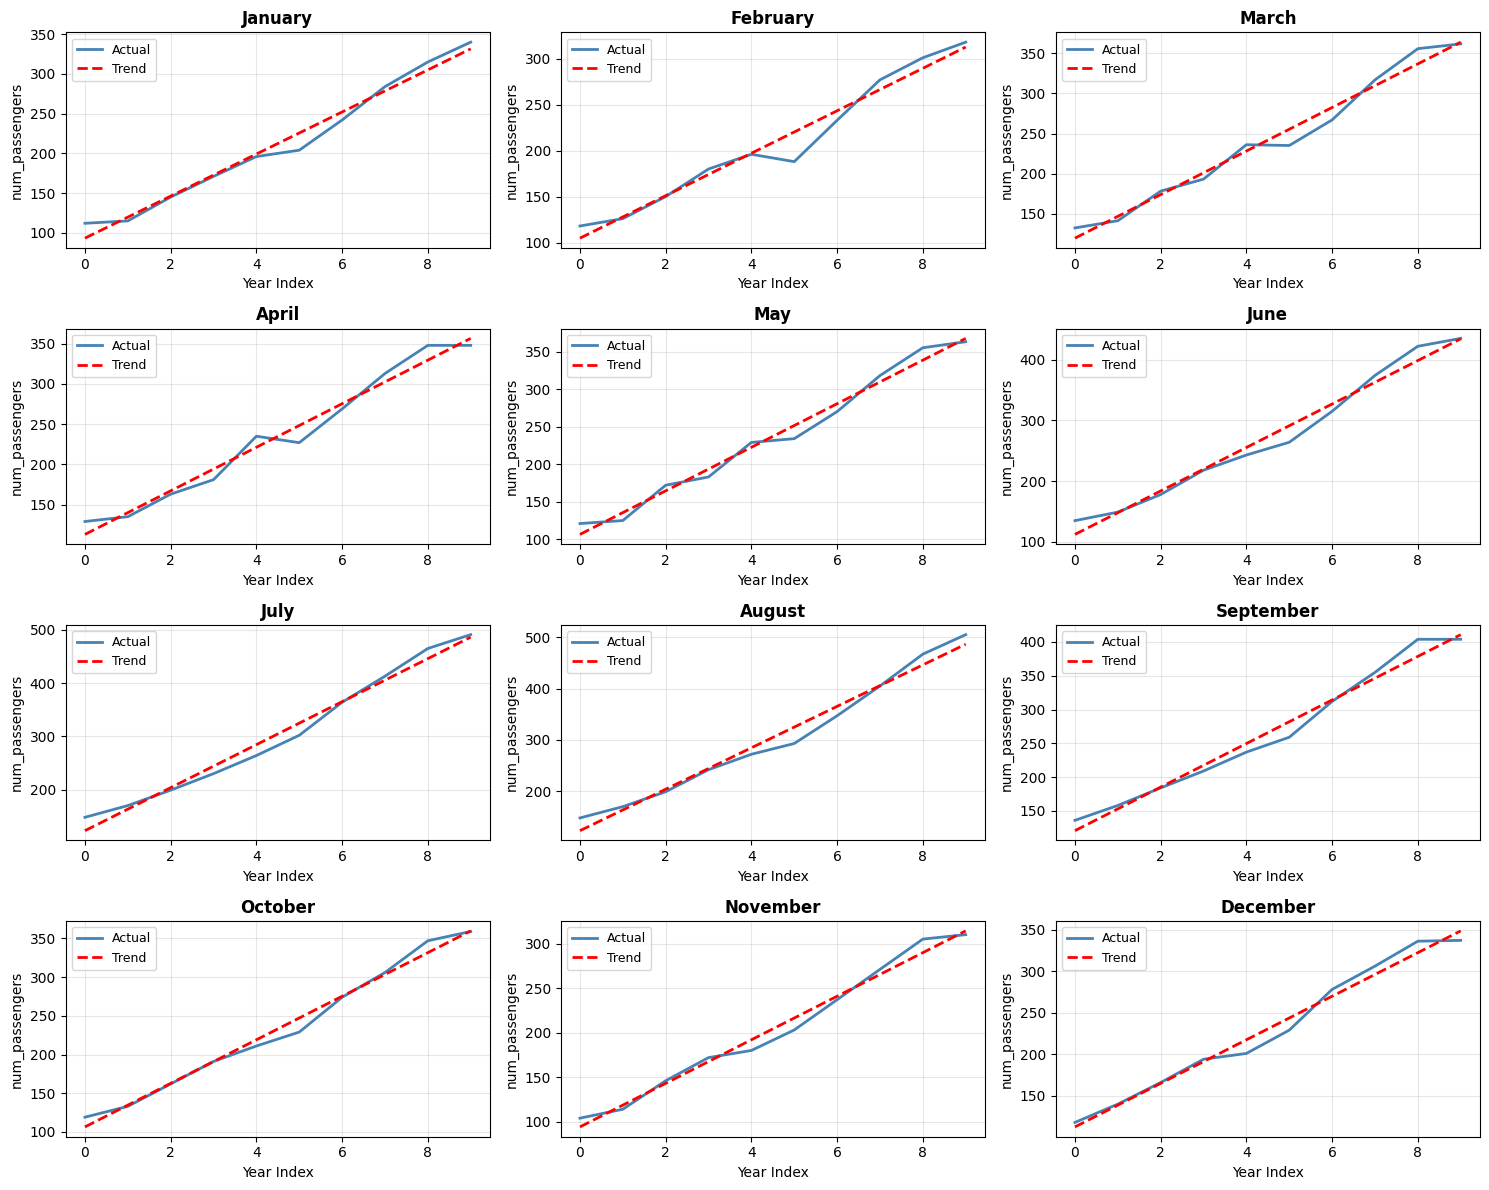

In [34]:
plot_by_month(train, date_col="month", value_col="num_passengers")

Ok, if we remove the trend, then this data should be stationary. Let's see the 
seasonality in more detail

In [35]:
def plot_seasonality(df, date_col="Month", value_col="Count"):
    """
    Plot average value per calendar month (seasonality pattern).

    Args:
        df: DataFrame with datetime column
        date_col: Name of datetime column
        value_col: Name of value column to plot
    """
    df_copy = df.copy()
    df_copy["Month_Num"] = pd.to_datetime(df_copy[date_col]).dt.month

    # Group by month and calculate mean
    monthly_avg = df_copy.groupby("Month_Num")[value_col].mean()

    months = [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ]

    fig, ax = plt.subplots(figsize=(12, 5))

    # Bar chart
    x = monthly_avg.index - 1  # 0-indexed for plotting
    ax.bar(x, monthly_avg.values, alpha=0.6, color="steelblue", label="Average")

    # Connecting line
    ax.plot(
        x,
        monthly_avg.values,
        "r-",
        linewidth=2,
        marker="o",
        markersize=6,
        label="Trend",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(months)
    ax.set_title("Average Seasonality by Month", fontsize=14, fontweight="bold")
    ax.set_xlabel("Month", fontsize=12)
    ax.set_ylabel(value_col, fontsize=12)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()


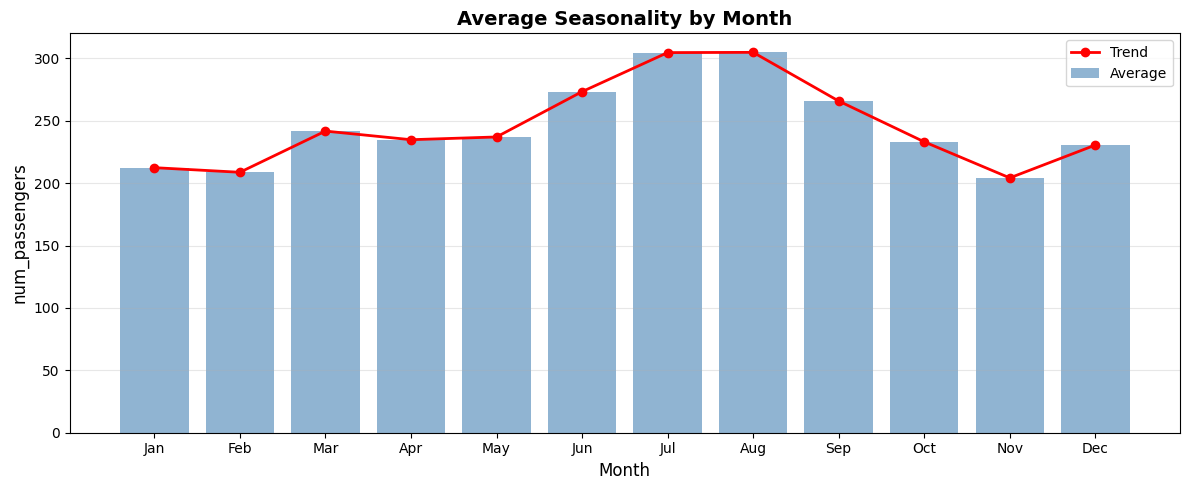

In [36]:
plot_seasonality(train, date_col="month", value_col="num_passengers")

I'd expect June / July / August to definitely have non-zero coefficients. Maybe something
for Mar / Apr / May, and Sep / Oct.

> ***What about year?***

We don't really need to do this for the year, since the `time_period` trend line would
account for the fact that number of passengers are rising each year

#### Data Processing

We want to include the month to our main df here

In [37]:
df.loc[:, "month_name"] = df.month.apply(lambda x: x.month_name())
df.head()

,month,num_passengers,time_period,num_passengers_last_month,month_name
0,1949-01-01,112,0,NaN,January
1,1949-02-01,118,1,112.0,February
2,1949-03-01,132,2,118.0,March
3,1949-04-01,129,3,132.0,April
4,1949-05-01,121,4,129.0,May


#### Resplit to get the new column

In [ ]:
train, test = train_test_split_time_series(df, 1959)

train_actuals = train["num_passengers"]
test_actual = test["num_passengers"]

#### OLS with time_period and month dummies **only**

In [39]:
lm_with_dummies = smf.ols(
    formula="num_passengers ~ time_period + month_name", data=train
).fit()
print(lm_with_dummies.summary())

                            OLS Regression Results                            
Dep. Variable:         num_passengers   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     154.0
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           1.19e-56
Time:                        02:06:40   Log-Likelihood:                -470.31
No. Observations:                 108   AIC:                             966.6
Df Residuals:                      95   BIC:                             1001.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

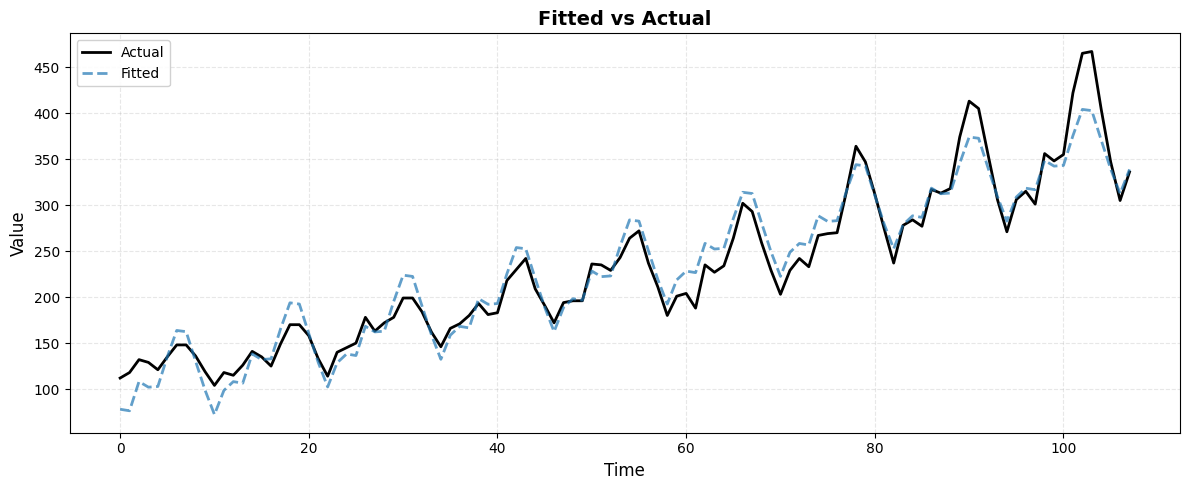

In [40]:
plot_fitted_vs_actual(train_actuals, lm_with_dummies)

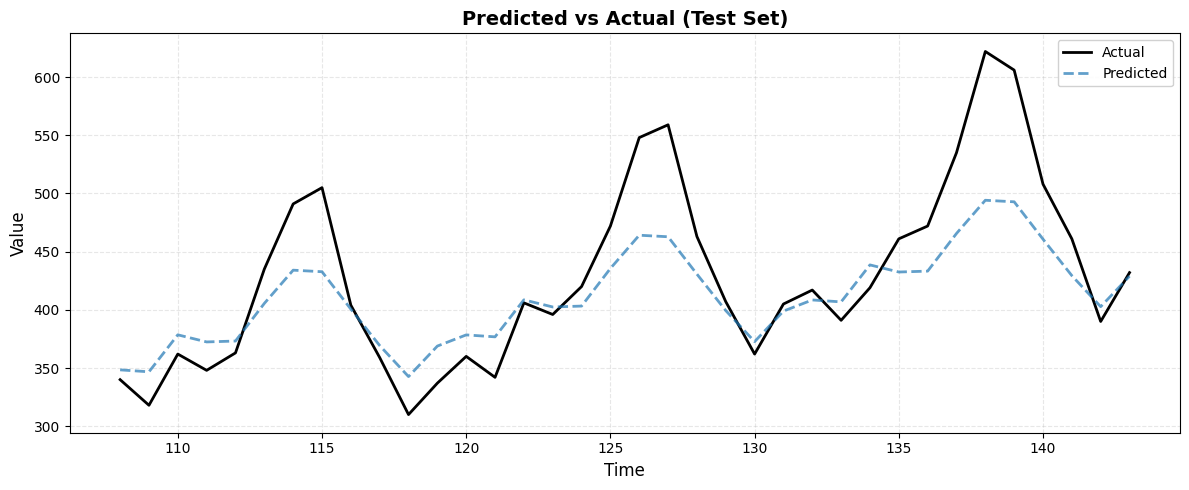

In [41]:
test_pred = lm_with_dummies.predict(test)
plot_predicted_vs_actual(test_actual, test_pred)

This is pretty good! But, the low Durbin Watson test tests for auto-correlation in the
residuals. The idea is that a value of 2.0 means there is no autocorrelation, but a 
value close to 0 means that there is strong positive autocorrelation. 

#### Throw autoregressive term into it as well

In [42]:
seasonal_ar_1_with_trend = smf.ols(
    formula="num_passengers ~ time_period + num_passengers_last_month + month_name",
    data=train,
).fit()
print(seasonal_ar_1_with_trend.summary())


                            OLS Regression Results                            
Dep. Variable:         num_passengers   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     426.7
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           8.57e-77
Time:                        02:06:40   Log-Likelihood:                -407.31
No. Observations:                 107   AIC:                             842.6
Df Residuals:                      93   BIC:                             880.0
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

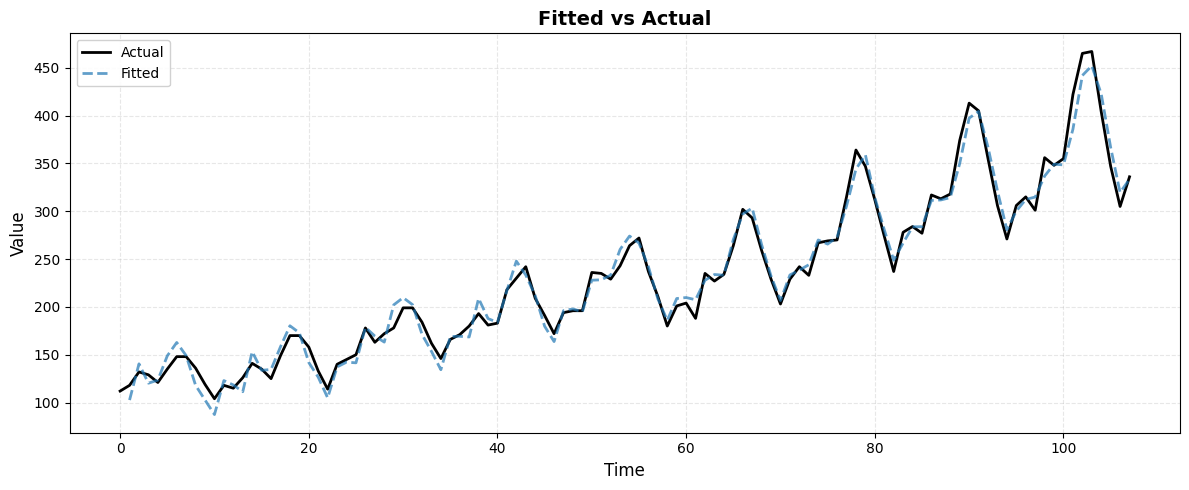

In [43]:
plot_fitted_vs_actual(train_actuals, seasonal_ar_1_with_trend)

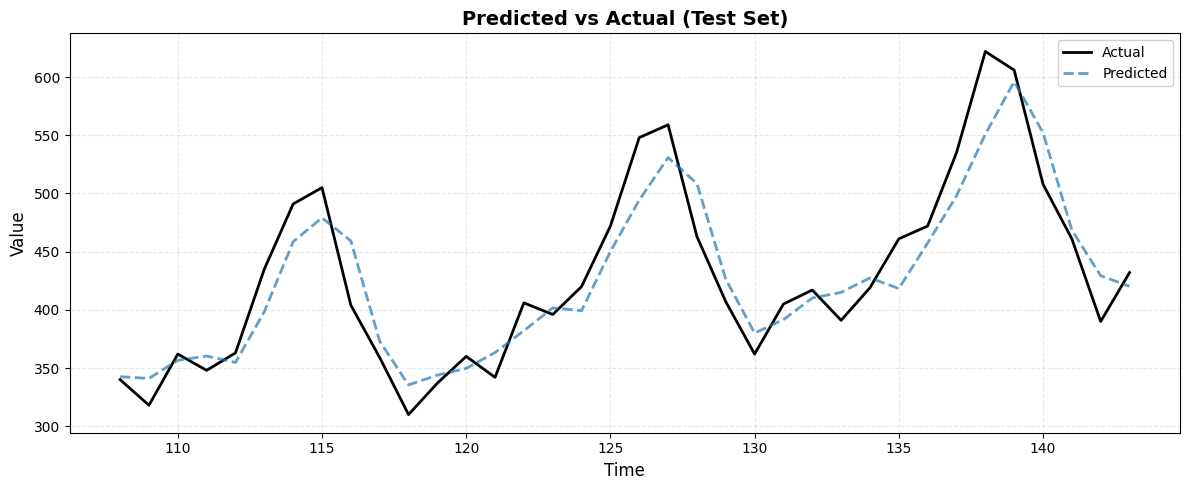

In [44]:
test_pred = seasonal_ar_1_with_trend.predict(test)
plot_predicted_vs_actual(test_actual, test_pred)

Much better

Durbin Watson is also quite close 2, which implies that almost no auto-correlation
in the residuals. It also predicts the test data much better than the previous model

#### Can we improve the auto-correlation by removing the time_period

My thinking here is that the time_period and the AR(1) term might both be contributing
to the overall trend. So removing one, might improve our multi-collineaity warning that
exists.

In [45]:
seasonal_ar_1_no_trend = smf.ols(
    formula="num_passengers ~ num_passengers_last_month + month_name",
    data=train,
).fit()
print(seasonal_ar_1_no_trend.summary())

                            OLS Regression Results                            
Dep. Variable:         num_passengers   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     414.2
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           1.00e-75
Time:                        02:06:40   Log-Likelihood:                -413.64
No. Observations:                 107   AIC:                             853.3
Df Residuals:                      94   BIC:                             888.0
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

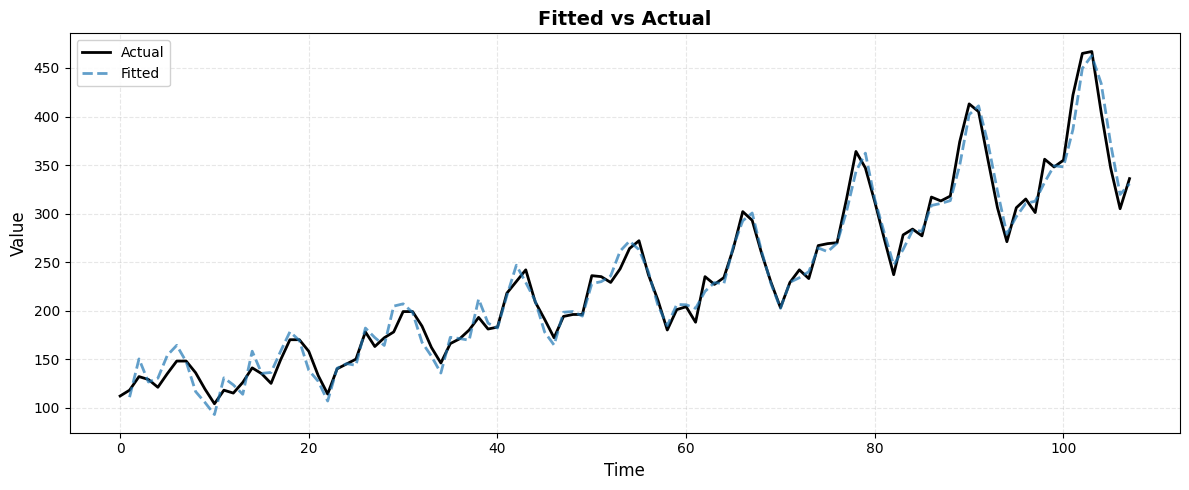

In [46]:
plot_fitted_vs_actual(train_actuals, seasonal_ar_1_no_trend)

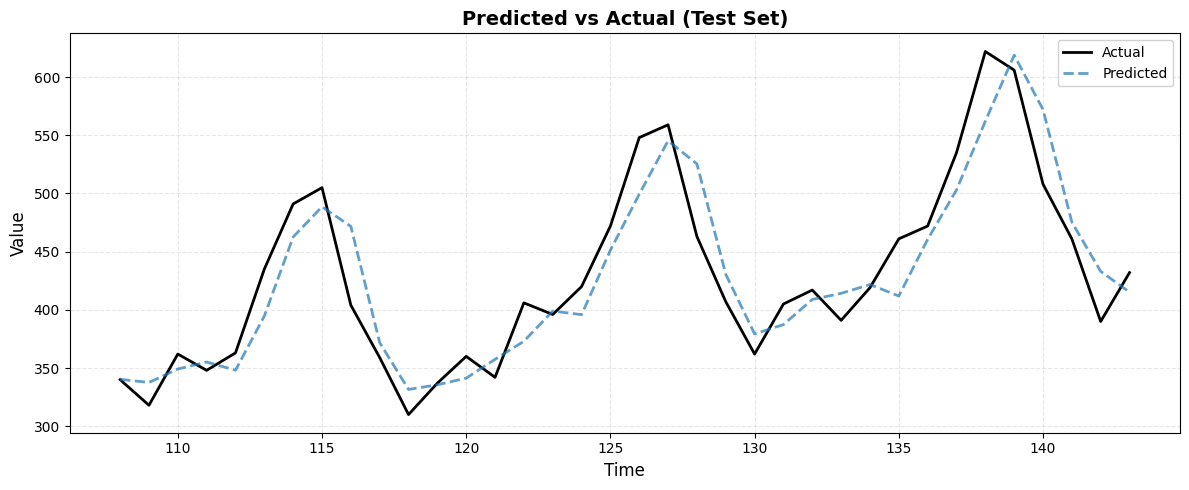

In [47]:
test_pred = seasonal_ar_1_no_trend.predict(test)
plot_predicted_vs_actual(test_actual, test_pred)

#### Look at `with_time_period` and `without_time_period` predictions together

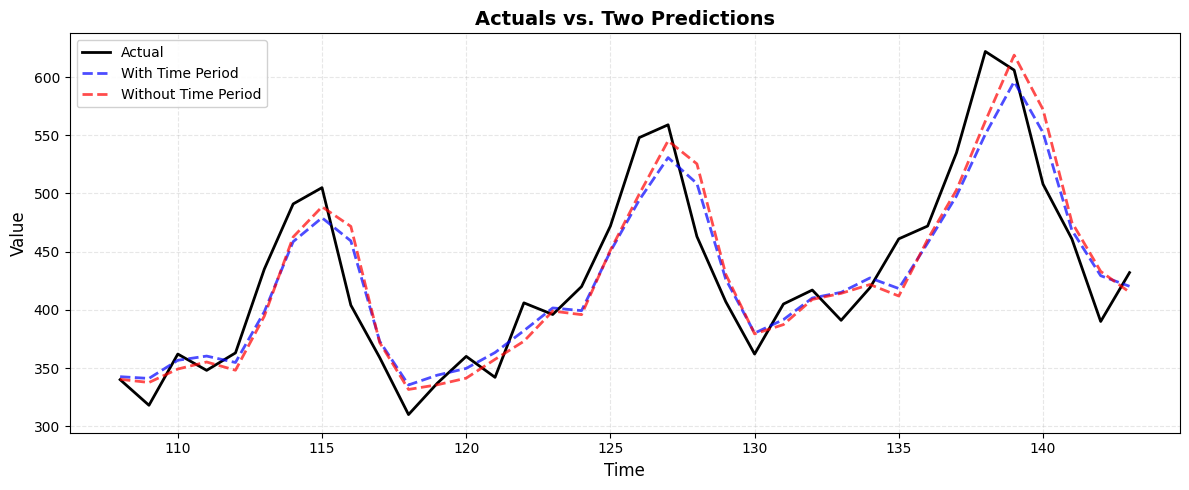

In [48]:
test_pred_with_trend = seasonal_ar_1_with_trend.predict(test)
test_pred_without_trend = seasonal_ar_1_no_trend.predict(test)
# plot_predicted_vs_actual(test_actual, test_pred)

plot_compare_predictions(
    test_actual,
    test_pred_with_trend,
    test_pred_without_trend,
    labels=("With Time Period", "Without Time Period"),
)

In [49]:
osr2_with_trend = r2_score(test_actual, test_pred_with_trend)
osr2_without_trend = r2_score(test_actual, test_pred_without_trend)
print(f"OSR^2 with trend:    {osr2_with_trend:.4f}")
print(f"OSR^2 without trend: {osr2_without_trend:.4f}")


OSR^2 with trend:    0.8663
OSR^2 without trend: 0.8481


While removing the trend term does increase the Durbin Watson statistic, it looks like
it is explaining more of the variation for the test set. 

#### Remove months one-by-one

The results of the model with all seasonality features, the trend line, and the 
auto-regressive terms are:

```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         num_passengers   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     426.7
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           8.57e-77
Time:                        00:42:14   Log-Likelihood:                -407.31
No. Observations:                 107   AIC:                             842.6
Df Residuals:                      93   BIC:                             880.0
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    13.5082      7.395      1.827      0.071      -1.177      28.193
month_name[T.August]         13.9764      6.141      2.276      0.025       1.781      26.172
month_name[T.December]       20.8212      6.445      3.231      0.002       8.024      33.619
month_name[T.February]       -0.6296      5.706     -0.110      0.912     -11.961      10.701
month_name[T.January]         4.5814      5.986      0.765      0.446      -7.305      16.468
month_name[T.July]           38.5815      5.628      6.855      0.000      27.405      49.757
month_name[T.June]           36.3068      5.540      6.553      0.000      25.305      47.309
month_name[T.March]          31.9494      5.776      5.531      0.000      20.479      43.419
month_name[T.May]             5.1192      5.530      0.926      0.357      -5.861      16.100
month_name[T.November]      -26.1157      5.738     -4.551      0.000     -37.510     -14.721
month_name[T.October]       -23.8809      5.526     -4.322      0.000     -34.854     -12.907
month_name[T.September]     -17.5989      6.044     -2.912      0.005     -29.602      -5.596
time_period                   0.5263      0.154      3.419      0.001       0.221       0.832
num_passengers_last_month     0.7965      0.060     13.350      0.000       0.678       0.915
==============================================================================
Omnibus:                        3.225   Durbin-Watson:                   1.536
Prob(Omnibus):                  0.199   Jarque-Bera (JB):                2.749
Skew:                           0.385   Prob(JB):                        0.253
Kurtosis:                       3.158   Cond. No.                     3.23e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.23e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
```

From this, we can see that the following moths are significant:

**December, July, June, March, November, October, September**

So, let's create a column which is `Baseline` if the month ain't in the above list

In [56]:
significant_months = [
    "December",
    "July",
    "June",
    "March",
    "November",
    "October",
    "September",
]
df["month_group"] = df["month_name"].apply(
    lambda x: x if x in significant_months else "Baseline"
)

train, test = train_test_split_time_series(df, 1959)
train_actuals = train["num_passengers"]
test_actual = test["num_passengers"]

In [57]:
ar_1_with_grouped_months = smf.ols(
    formula="num_passengers ~ time_period+ num_passengers_last_month + month_group",
    data=train,
).fit()
print(ar_1_with_grouped_months.summary())

                            OLS Regression Results                            
Dep. Variable:         num_passengers   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     581.0
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           8.71e-88
Time:                        02:08:09   Log-Likelihood:                -478.15
No. Observations:                 119   AIC:                             976.3
Df Residuals:                     109   BIC:                             1004.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [58]:
test["month_group"] = test["month_name"].apply(
    lambda x: x if x in significant_months else "Baseline"
)

/var/folders/jh/9_qy7nd96v9_q0_x1sffyq9c0000gn/T/ipykernel_74993/3077337421.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["month_group"] = test["month_name"].apply(


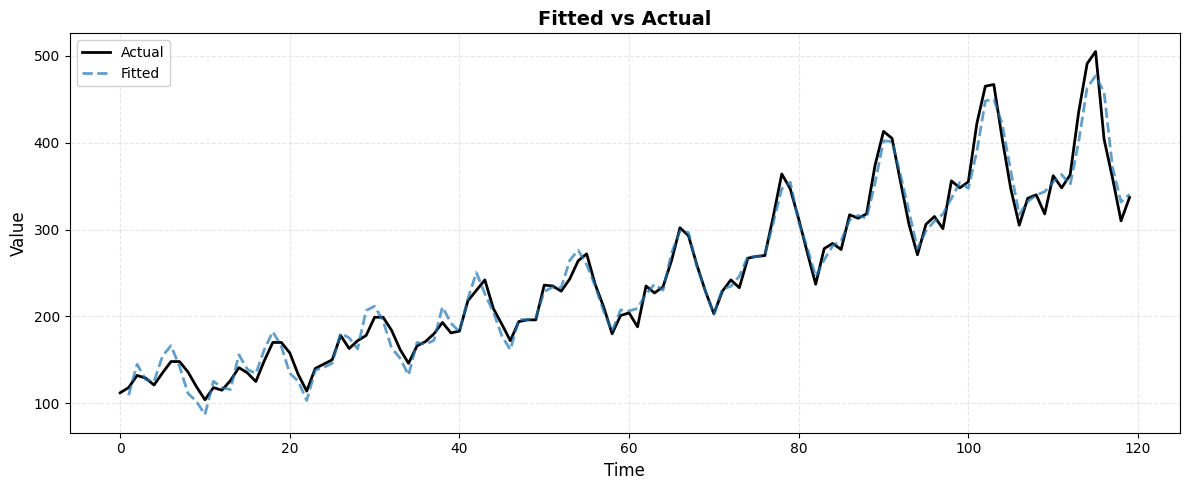

In [59]:
plot_fitted_vs_actual(train_actuals, ar_1_with_grouped_months)

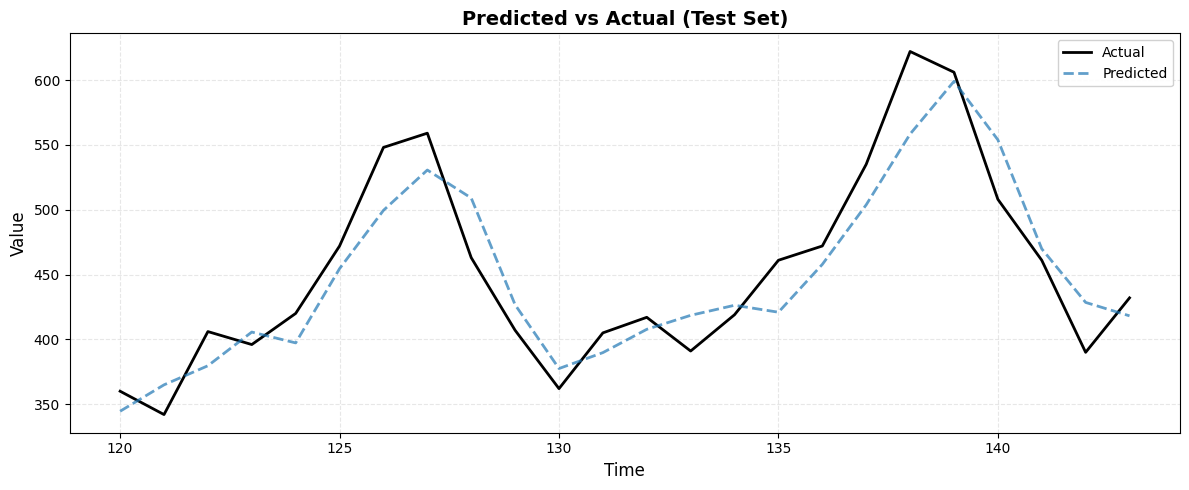

In [60]:
test_pred = ar_1_with_grouped_months.predict(test)
plot_predicted_vs_actual(test_actual, test_pred)

In [61]:
osr2_grouped_months = r2_score(test_actual, test_pred)
print(f"OSR^2 with grouped months and trend:    {osr2_grouped_months:.4f}")

OSR^2 with grouped months and trend:    0.8494


So it's not actually explaining as much of the test data as the previous model was.

#### Any more AR terms?

There's a plot called the ACF plot which tells us how the residuals of our current model
are correlated with the residuals from the past. If it is highly correlated (postiively)
, or negatively, then there's a case to add another AR term

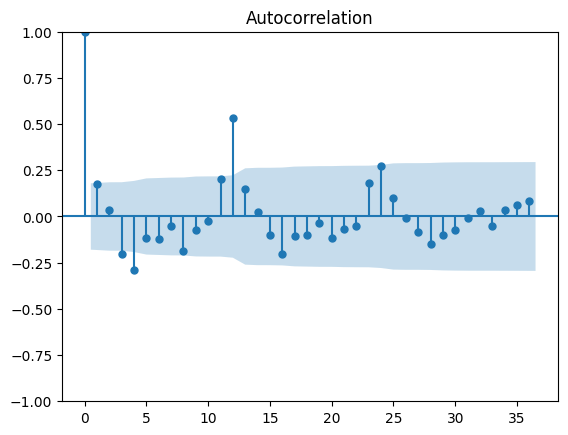

In [62]:
residuals = ar_1_with_grouped_months.resid
plot_acf(residuals, lags=36)
plt.show()

Big spike at n = 12, and smaller spike at n = 5. Let's add an n=12 lag term, look at 
the results, and re-examine the ACF

In [63]:
df["num_passengers_last_year"] = df["num_passengers"].shift(12)
train, test = train_test_split_time_series(df, 1959)
train.tail()

,month,num_passengers,time_period,num_passengers_last_month,month_name,month_group,num_passengers_last_year
115,1958-08-01,505,115,491.0,August,Baseline,467.0
116,1958-09-01,404,116,505.0,September,September,404.0
117,1958-10-01,359,117,404.0,October,October,347.0
118,1958-11-01,310,118,359.0,November,November,305.0
119,1958-12-01,337,119,310.0,December,December,336.0


#### Add AR(12) term 

In [64]:
ar_1_12_grouped_months = smf.ols(
    "num_passengers ~ month_group + num_passengers_last_month + num_passengers_last_year + time_period",
    data=train,
).fit()
print(ar_1_12_grouped_months.summary())

                            OLS Regression Results                            
Dep. Variable:         num_passengers   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     629.4
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           1.63e-83
Time:                        02:08:26   Log-Likelihood:                -413.46
No. Observations:                 108   AIC:                             848.9
Df Residuals:                      97   BIC:                             878.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

#### Time Period is insignificant?

Time Period's p-value just shot up to 0.938, so migh tbe insignificant. So did the 
intercept. Let's go one at a time and remove time period first.

In [65]:
ar_1_12_grouped_months_no_trend = smf.ols(
    "num_passengers ~ month_group + num_passengers_last_month + num_passengers_last_year",
    data=train,
).fit()
print(ar_1_12_grouped_months_no_trend.summary())


                            OLS Regression Results                            
Dep. Variable:         num_passengers   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     706.5
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           5.96e-85
Time:                        02:08:28   Log-Likelihood:                -413.46
No. Observations:                 108   AIC:                             846.9
Df Residuals:                      98   BIC:                             873.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

OK, looks better. The intercept term is now insignificant. Looks like the math has
changed completely once we added the AR(12) term. What happens if we throw out the
seasonality altogether?


In [66]:
ar_1_12 = smf.ols(
    "num_passengers ~ num_passengers_last_month + num_passengers_last_year",
    data=train,
).fit()
print(ar_1_12.summary())

                            OLS Regression Results                            
Dep. Variable:         num_passengers   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     1962.
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           6.89e-84
Time:                        02:08:30   Log-Likelihood:                -442.65
No. Observations:                 108   AIC:                             891.3
Df Residuals:                     105   BIC:                             899.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

#### Residual Analysis

Let's do a sanity check on the residuals of all the three models we just did

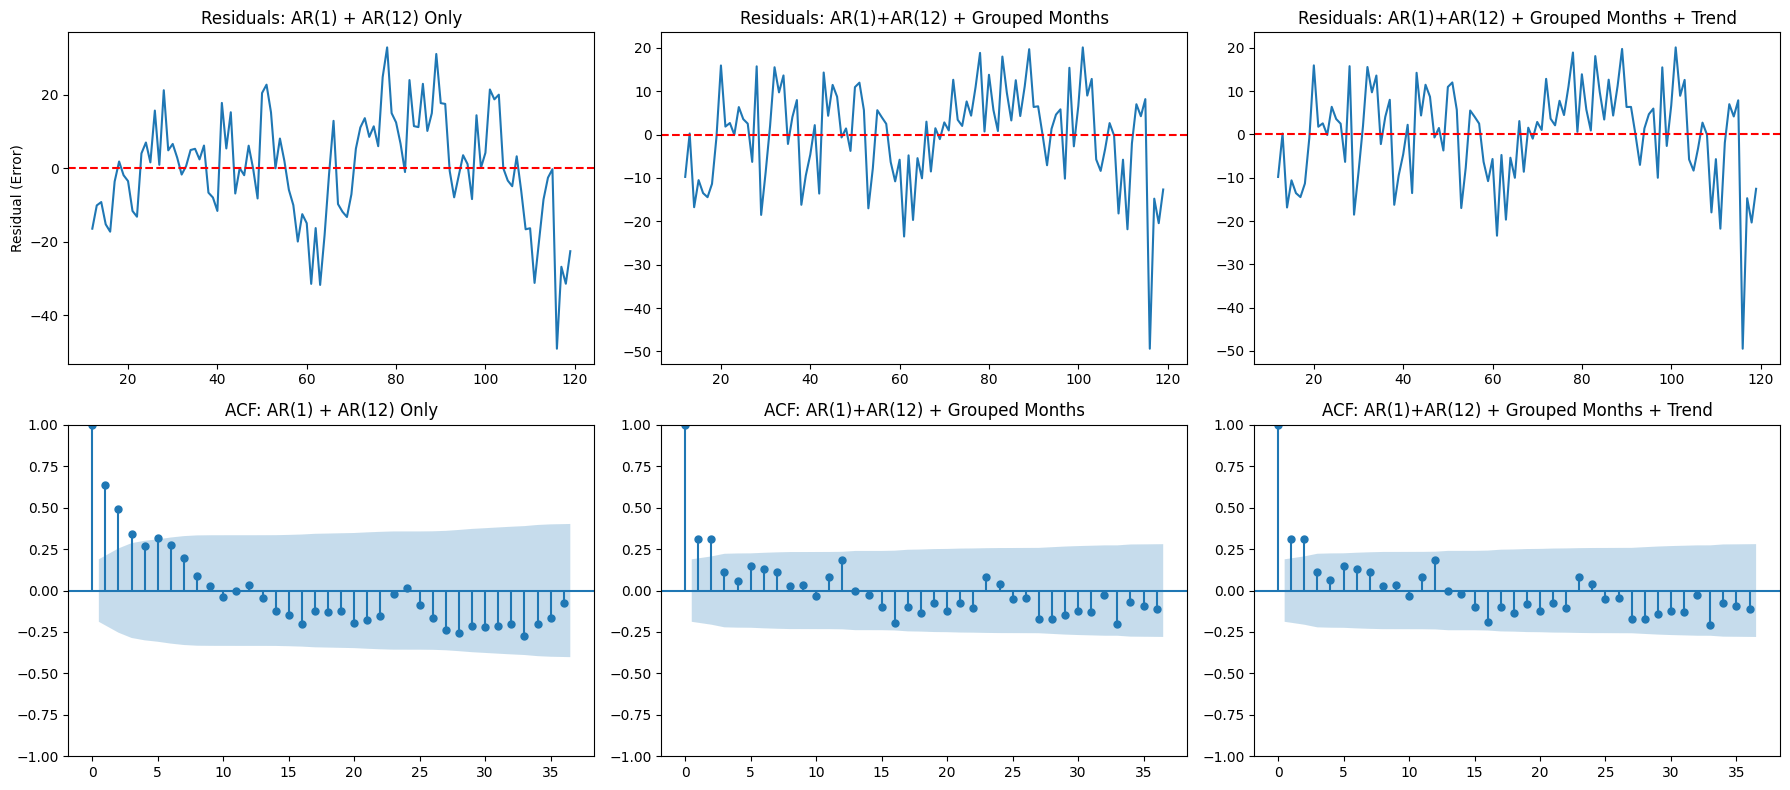

In [67]:
# models are:
# ar_1_12:                            only AR(1) and AR(12) terms
# ar_1_12_grouped_months_no_trend:    above with grouped months
# ar_1_12_grouped_months:             above with trend

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 8), sharex="row")

# Row 1

# Model 1: ar_1_12
ax[0, 0].plot(ar_1_12.resid)
ax[0, 0].axhline(0, color="red", linestyle="--")
ax[0, 0].set_title("Residuals: AR(1) + AR(12) Only")
ax[0, 0].set_ylabel("Residual (Error)")

# Model 2: ar_1_12_grouped_months_no_trend
ax[0, 1].plot(ar_1_12_grouped_months_no_trend.resid)
ax[0, 1].axhline(0, color="red", linestyle="--")
ax[0, 1].set_title("Residuals: AR(1)+AR(12) + Grouped Months")

# Model 3: ar_1_12_grouped_months
ax[0, 2].plot(ar_1_12_grouped_months.resid)
ax[0, 2].axhline(0, color="red", linestyle="--")
ax[0, 2].set_title("Residuals: AR(1)+AR(12) + Grouped Months + Trend")

# Row 2

# Model 1: ar_1_12
plot_acf(ar_1_12.resid, lags=36, ax=ax[1, 0])
ax[1, 0].set_title("ACF: AR(1) + AR(12) Only")

# Model 2: ar_1_12_grouped_months_no_trend
plot_acf(ar_1_12_grouped_months_no_trend.resid, lags=36, ax=ax[1, 1])
ax[1, 1].set_title("ACF: AR(1)+AR(12) + Grouped Months")

# Model 3: ar_1_12_grouped_months
plot_acf(ar_1_12_grouped_months.resid, lags=36, ax=ax[1, 2])
ax[1, 2].set_title("ACF: AR(1)+AR(12) + Grouped Months + Trend")

plt.tight_layout()
plt.show()

##### Insights

**Only AR(1) + AR(12) is incomplete**

The ACF plot clearly shows that there is some dependency on the 1st and 2nd following 
periods. Those spikes vanish when we add the grouped months (see 2nd row, middle and 
right) plots. My conclusion is that the grouped months better captures the seasonality.

**Time Period is complicated the model**

The residuals for `AR(1) + AR(12) + Grouped Months` are identical to `AR(1) + AR(12) + Grouped Months + Trend`.
The implies that the time_period trend line isn't actually adding any explanation to the residuals,
and is just overcomplicating the model

**Verdict**

Go with AR(1) + AR(12) + Grouped Months 

#### (c): Final Answer

The final model is:

$$
\begin{align*}
    \text{Passengers}_{t} = ~ & 7.1816 \\
    & + 14.8647 \cdot \text{December} \\
    & + 22.7681 \cdot \text{July} \\
    & + 24.3664 \cdot \text{June} \\
    & + 19.4500 \cdot \text{March} \\
    & - 18.3913 \cdot \text{November} \\
    & - 19.5594 \cdot \text{October} \\
    & - 23.1310 \cdot \text{September} \\
    & + 0.5702 \cdot \text{Passengers}_{t-1} \\
    & + 0.4489 \cdot \text{Passengers}_{t-12}
\end{align*}
$$

Final model R-squared: 0.9848
Final model OSR^2:     0.9312


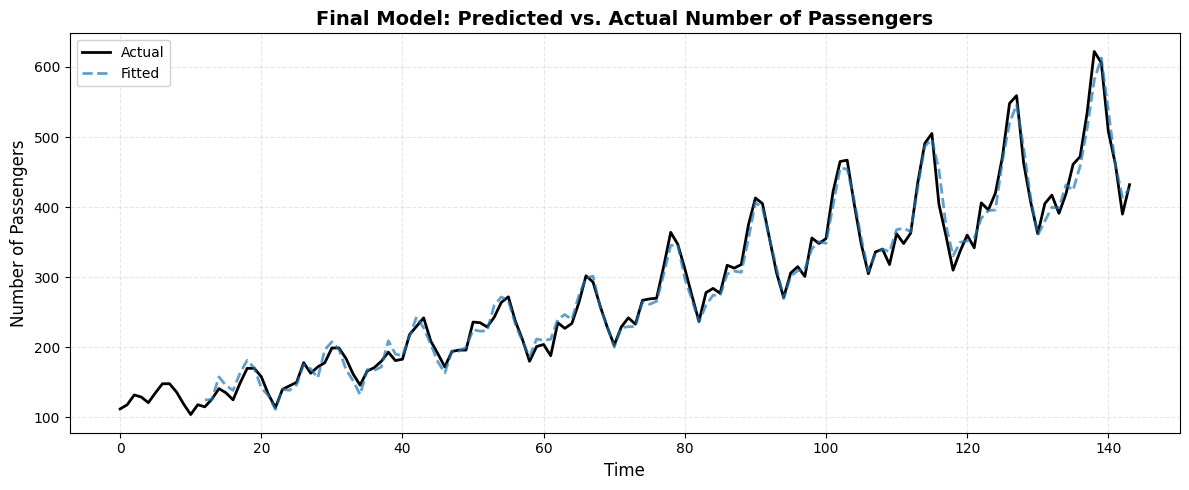

In [68]:
print(f"Final model R-squared: {ar_1_12_grouped_months_no_trend.rsquared:.4f}")

test_actual = test["num_passengers"]
osr2 = r2_score(test_actual, ar_1_12_grouped_months_no_trend.predict(test))
print(f"Final model OSR^2:     {osr2:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

y_actual = df["num_passengers"]
y_pred = ar_1_12_grouped_months_no_trend.predict(df)

ax.plot(y_actual, label="Actual", linewidth=2, color="black")
ax.plot(y_pred, label="Fitted", linewidth=2, alpha=0.7, linestyle="--")
ax.set_title(
    "Final Model: Predicted vs. Actual Number of Passengers",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Number of Passengers", fontsize=12)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="best", framealpha=0.9)

plt.tight_layout()
plt.show()

### (d) Random Forest

#### First one-hot encode

In [69]:
# One-hot encode month_group
train_encoded = pd.get_dummies(train, columns=["month_group"], drop_first=True)
test_encoded = pd.get_dummies(test, columns=["month_group"], drop_first=True)

# Now your features include the dummy columns
features = [col for col in train_encoded.columns if col.startswith("month_group_")] + [
    "num_passengers_last_month",
    "num_passengers_last_year",
]

X_train = train_encoded[features]
y_train = train_encoded["num_passengers"]
X_test = test_encoded[features]


#### Set up K-fold

In [70]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Define hyperparameters to test
param_grid = {"n_estimators": [10, 50, 100, 200]}

# TimeSeriesSplit for time series data
tscv = TimeSeriesSplit(n_splits=5)

# GridSearchCV with R^2 scoring
rf_cv = GridSearchCV(
    RandomForestRegressor(random_state=42), param_grid, cv=tscv, scoring="r2", n_jobs=-1
)

#### Fit!

In [71]:
rf_cv.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'n_estimators': [10, 50, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,10


#### RF Results

In [72]:
# Results
print(f"Best n_estimators: {rf_cv.best_params_['n_estimators']}")
print(f"Best CV R^2: {rf_cv.best_score_:.4f}")
print("\nCV Results:")
print(
    pd.DataFrame(rf_cv.cv_results_)[
        ["param_n_estimators", "mean_test_score", "std_test_score"]
    ]
)

Best n_estimators: 10
Best CV R^2: 0.2699

CV Results:
   param_n_estimators  mean_test_score  std_test_score
0                  10         0.269908        0.399154
1                  50         0.254831        0.424493
2                 100         0.251318        0.459242
3                 200         0.238991        0.458962


#### Predict

In [73]:
# Predict on test set with best model
X_test = test_encoded[features]
y_pred_rf = rf_cv.best_estimator_.predict(X_test)
test_r2 = r2_score(test["num_passengers"], y_pred_rf)
print(f"OSR^2: {test_r2:.4f}")

OSR^2: 0.6668


#### Plot

Won't use my `plot_predicted_vs_actual` here because it's written for `statsmodels`, 
which preserve the time index. sklearn drops that stuff

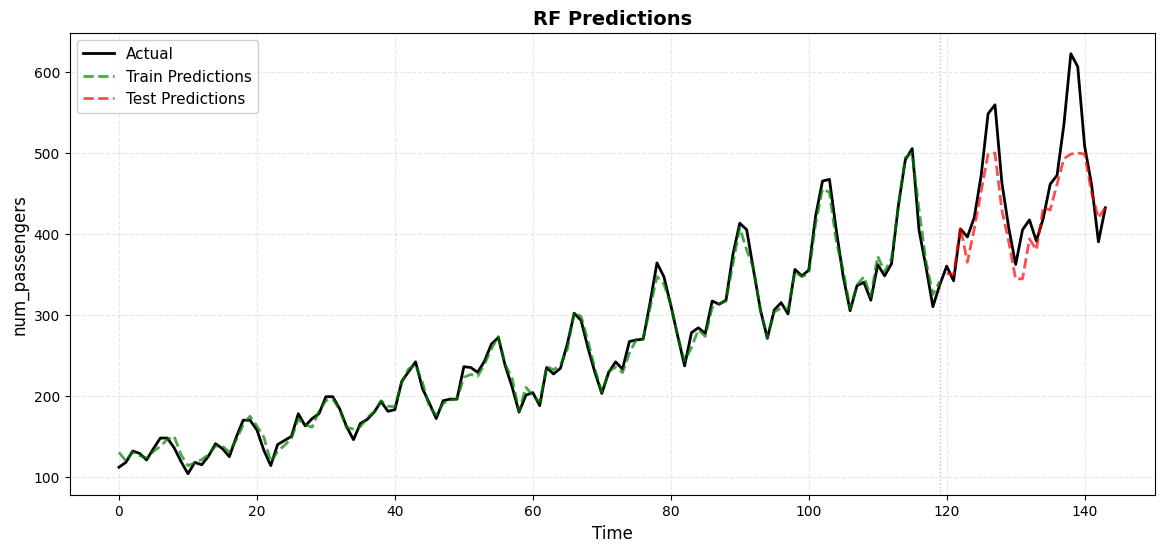

In [74]:
def plot_rf_predictions_full(
    ax,
    df,
    train,
    test,
    model,
    features,
    target="num_passengers",
    date_col="month",
    title="Random Forest Predictions vs Actual",
):
    """
    Plot RF predictions across full dataset (train + test).

    Args:
        df: Full original dataframe with proper time index
        train: Training subset
        test: Test subset
        model: Fitted RandomForest model
        features: List of feature column names
        target: Target column name
        date_col: DateTime column name
        title: Plot title
    """
    # Make predictions on train and test
    X_train = train[features]
    X_test = test[features]

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Get indices for alignment
    train_idx = train.index
    test_idx = test.index

    # Plot actual values (full dataset)
    ax.plot(df.index, df[target], label="Actual", linewidth=2, color="black")

    # Plot predictions on train set
    ax.plot(
        train_idx,
        y_train_pred,
        label="Train Predictions",
        linewidth=2,
        alpha=0.7,
        linestyle="--",
        color="green",
    )

    # Plot predictions on test set
    ax.plot(
        test_idx,
        y_test_pred,
        label="Test Predictions",
        linewidth=2,
        alpha=0.7,
        linestyle="--",
        color="red",
    )

    # Vertical line separating train/test
    ax.axvline(x=train.index[-1], color="gray", linestyle=":", linewidth=1, alpha=0.5)

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel(target, fontsize=12)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="best", framealpha=0.9, fontsize=11)

    return ax


fig, ax = plt.subplots(figsize=(14, 6))
ax = plot_rf_predictions_full(
    ax,
    df,
    train_encoded,
    test_encoded,
    rf_cv.best_estimator_,
    features,
    title="RF Predictions",
)
# plt.show()

#### Compare Random Forest with (c)

MODEL COMPARISON
Random Forest Test R^2: 0.6668
OLS Test R^2:           0.9312



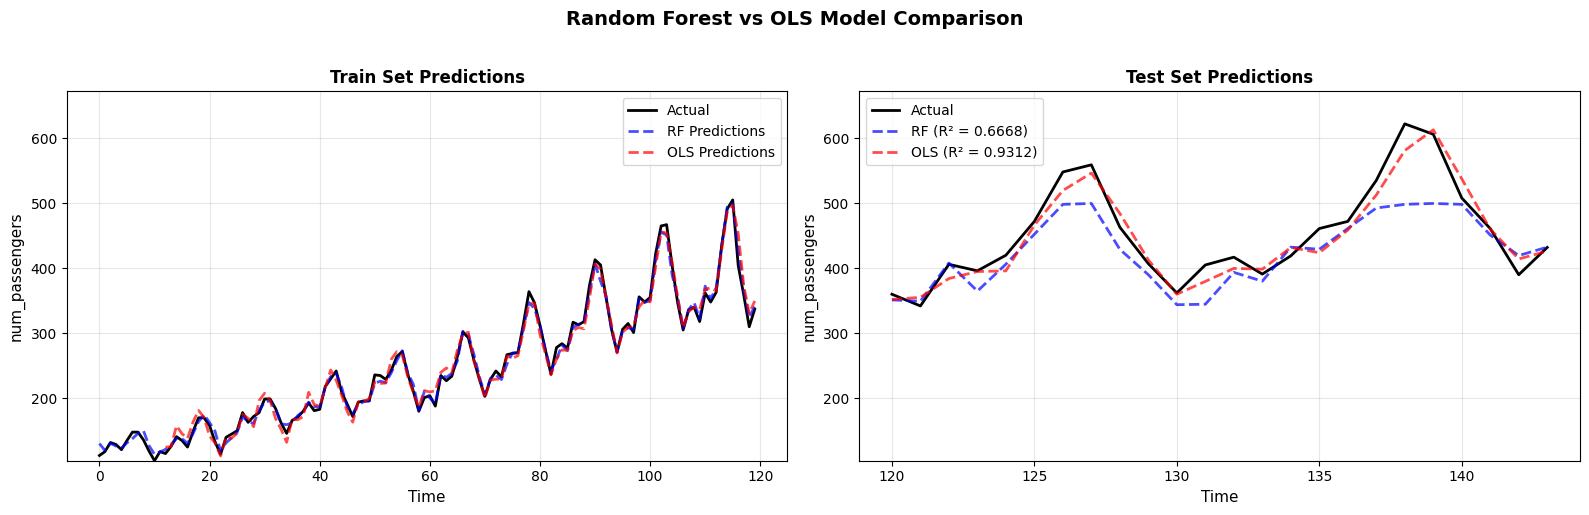

In [75]:
def compare_models(
    df,
    train,
    test,
    train_encoded,
    test_encoded,
    rf_model,
    ols_model,
    features,
    target="num_passengers",
    title="RF vs OLS Predictions",
):
    """
    Compare RF and OLS model predictions on train and test sets.

    Args:
        df: Full original dataframe
        train: Training subset (original, not encoded)
        test: Test subset (original, not encoded)
        train_encoded: Training subset (one-hot encoded for RF)
        test_encoded: Test subset (one-hot encoded for RF)
        rf_model: Fitted RandomForest model
        ols_model: Fitted statsmodels OLS model
        features: List of feature column names for RF
        target: Target column name
        title: Plot title
    """
    # RF Predictions
    X_train_rf = train_encoded[features]
    X_test_rf = test_encoded[features]
    y_train_pred_rf = rf_model.predict(X_train_rf)
    y_test_pred_rf = rf_model.predict(X_test_rf)

    # OLS Predictions
    y_train_pred_ols = ols_model.predict(train)
    y_test_pred_ols = ols_model.predict(test)

    # Get actual values
    y_train_actual = train[target].values
    y_test_actual = test[target].values

    # Calculate test R^2
    r2_rf = r2_score(y_test_actual, y_test_pred_rf)
    r2_ols = r2_score(y_test_actual, y_test_pred_ols)

    # Print metrics
    print("=" * 70)
    print("MODEL COMPARISON")
    print("=" * 70)
    print(f"Random Forest Test R^2: {r2_rf:.4f}")
    print(f"OLS Test R^2:           {r2_ols:.4f}")
    print()

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Train set comparison
    ax = axes[0]
    ax.plot(train.index, y_train_actual, label="Actual", linewidth=2, color="black")
    ax.plot(
        train.index,
        y_train_pred_rf,
        label="RF Predictions",
        linewidth=2,
        alpha=0.7,
        linestyle="--",
        color="blue",
    )
    ax.plot(
        train.index,
        y_train_pred_ols,
        label="OLS Predictions",
        linewidth=2,
        alpha=0.7,
        linestyle="--",
        color="red",
    )
    ax.set_title("Train Set Predictions", fontsize=12, fontweight="bold")
    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel(target, fontsize=11)
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    # Test set comparison
    ax = axes[1]
    ax.plot(test.index, y_test_actual, label="Actual", linewidth=2, color="black")
    ax.plot(
        test.index,
        y_test_pred_rf,
        label=f"RF (R² = {r2_rf:.4f})",
        linewidth=2,
        alpha=0.7,
        linestyle="--",
        color="blue",
    )
    ax.plot(
        test.index,
        y_test_pred_ols,
        label=f"OLS (R² = {r2_ols:.4f})",
        linewidth=2,
        alpha=0.7,
        linestyle="--",
        color="red",
    )
    ax.set_title("Test Set Predictions", fontsize=12, fontweight="bold")
    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel(target, fontsize=11)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)

    # Set same y-axis scale for both plots
    y_min = min(y_train_actual.min(), y_test_actual.min())
    y_max = max(y_train_actual.max(), y_test_actual.max()) + 50
    axes[0].set_ylim(y_min, y_max)
    axes[1].set_ylim(y_min, y_max)

    plt.tight_layout()
    plt.show()


compare_models(
    df,
    train,
    test,
    train_encoded,
    test_encoded,
    rf_cv.best_estimator_,
    ar_1_12_grouped_months_no_trend,
    features=features,
    title="Random Forest vs OLS Model Comparison",
)

### (e) Dickey-Fuller test

In [76]:
part_e = df.copy()
part_e.head()

,month,num_passengers,time_period,num_passengers_last_month,month_name,month_group,num_passengers_last_year
0,1949-01-01,112,0,NaN,January,Baseline,NaN
1,1949-02-01,118,1,112.0,February,Baseline,NaN
2,1949-03-01,132,2,118.0,March,March,NaN
3,1949-04-01,129,3,132.0,April,Baseline,NaN
4,1949-05-01,121,4,129.0,May,Baseline,NaN


In [77]:
def adf_report(series, name="Series"):
    s = series.dropna().values
    result = adfuller(s, autolag="AIC")
    print(f"ADF test on {name}:")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f" p-value : {result[1]:.4f}")
    print(f" #Lags Used : {result[2]}")
    print(f" #Observations : {result[3]}")
    print("  Critical Values:")
    for k, v in result[4].items():
        print(f" {k}: {v:.4f}")
        print(
            " => Stationary?’ , ’Yes (reject H0)’ if result[1] < 0.05 else ’No (fail to reject H0)"
        )
        print()

In [78]:
part_e["differencing"] = part_e["num_passengers"].diff(1)
part_e["seasonal_differencing"] = part_e["num_passengers"].diff(12)

In [79]:
def plot_time_series(df, value_col, title="Time Series"):
    """
    Plot a time series from dataframe.

    Args:
        df: DataFrame with time series data
        value_col: Column name to plot
        title: Plot title
    """
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(df.index, df[value_col], linewidth=2, color="steelblue")

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel(value_col, fontsize=12)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.grid(True, alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()


#### Main Series

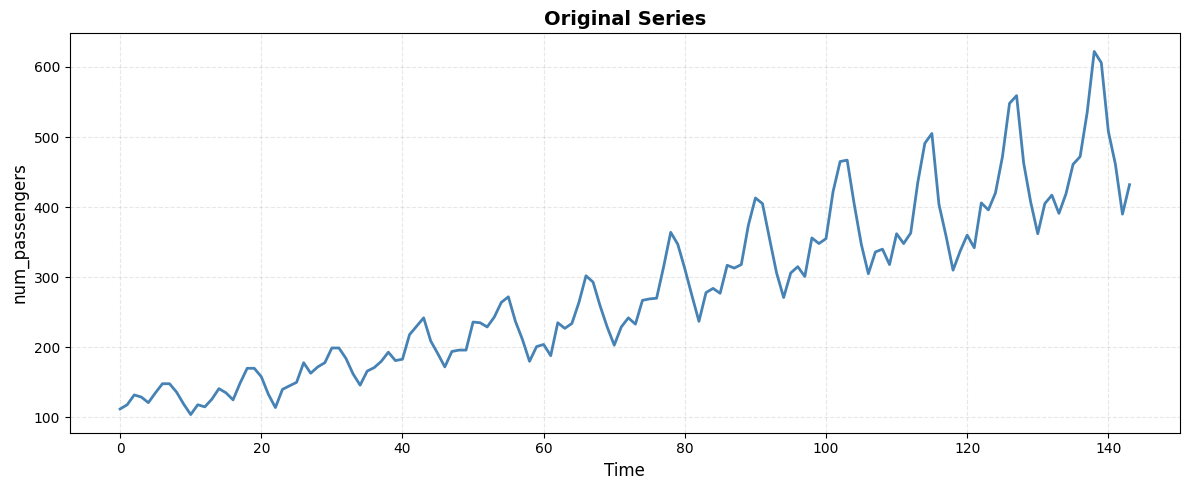

In [80]:
plot_time_series(part_e, "num_passengers", "Original Series")

In [81]:
adf_report(part_e["num_passengers"], name="Number of Passengers")

ADF test on Number of Passengers:
Test Statistic: 0.8154
 p-value : 0.9919
 #Lags Used : 13
 #Observations : 130
  Critical Values:
 1%: -3.4817
 => Stationary?’ , ’Yes (reject H0)’ if result[1] < 0.05 else ’No (fail to reject H0)

 5%: -2.8840
 => Stationary?’ , ’Yes (reject H0)’ if result[1] < 0.05 else ’No (fail to reject H0)

 10%: -2.5788
 => Stationary?’ , ’Yes (reject H0)’ if result[1] < 0.05 else ’No (fail to reject H0)



Definitely not stationary

#### Differencing Series

In [82]:
part_e.head()

,month,num_passengers,time_period,num_passengers_last_month,month_name,month_group,num_passengers_last_year,differencing,seasonal_differencing
0,1949-01-01,112,0,NaN,January,Baseline,NaN,NaN,NaN
1,1949-02-01,118,1,112.0,February,Baseline,NaN,6.0,NaN
2,1949-03-01,132,2,118.0,March,March,NaN,14.0,NaN
3,1949-04-01,129,3,132.0,April,Baseline,NaN,-3.0,NaN
4,1949-05-01,121,4,129.0,May,Baseline,NaN,-8.0,NaN


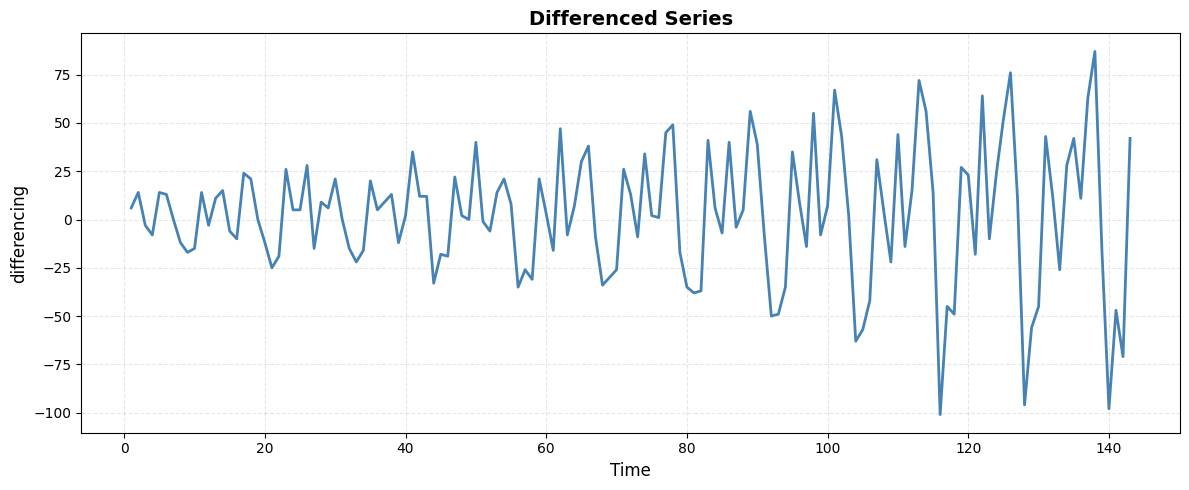

ADF test on Differenced Number of Passengers:
Test Statistic: -2.8293
 p-value : 0.0542
 #Lags Used : 12
 #Observations : 130
  Critical Values:
 1%: -3.4817
 => Stationary?’ , ’Yes (reject H0)’ if result[1] < 0.05 else ’No (fail to reject H0)

 5%: -2.8840
 => Stationary?’ , ’Yes (reject H0)’ if result[1] < 0.05 else ’No (fail to reject H0)

 10%: -2.5788
 => Stationary?’ , ’Yes (reject H0)’ if result[1] < 0.05 else ’No (fail to reject H0)



In [83]:
plot_time_series(part_e, "differencing", "Differenced Series")
adf_report(part_e["differencing"], name="Differenced Number of Passengers")

Not stationary because the variance is increasing. The p-value suggests it's slightly more than 5% chance that it is not stationary.

#### Seasonally differenced

In [84]:
part_e.head()

,month,num_passengers,time_period,num_passengers_last_month,month_name,month_group,num_passengers_last_year,differencing,seasonal_differencing
0,1949-01-01,112,0,NaN,January,Baseline,NaN,NaN,NaN
1,1949-02-01,118,1,112.0,February,Baseline,NaN,6.0,NaN
2,1949-03-01,132,2,118.0,March,March,NaN,14.0,NaN
3,1949-04-01,129,3,132.0,April,Baseline,NaN,-3.0,NaN
4,1949-05-01,121,4,129.0,May,Baseline,NaN,-8.0,NaN


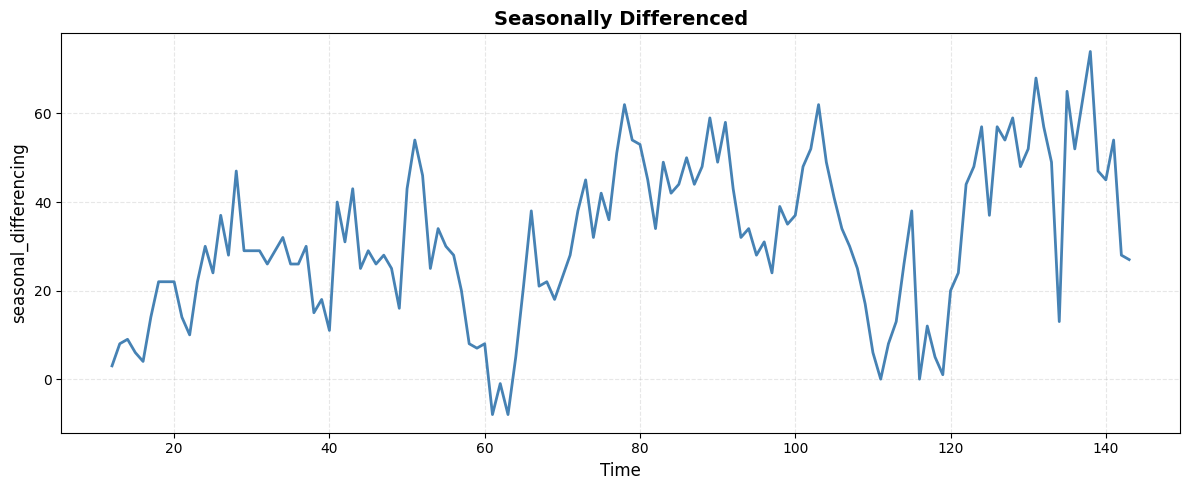

ADF test on Seasonally Differenced:
Test Statistic: -3.3830
 p-value : 0.0116
 #Lags Used : 1
 #Observations : 130
  Critical Values:
 1%: -3.4817
 => Stationary?’ , ’Yes (reject H0)’ if result[1] < 0.05 else ’No (fail to reject H0)

 5%: -2.8840
 => Stationary?’ , ’Yes (reject H0)’ if result[1] < 0.05 else ’No (fail to reject H0)

 10%: -2.5788
 => Stationary?’ , ’Yes (reject H0)’ if result[1] < 0.05 else ’No (fail to reject H0)



In [88]:
plot_time_series(part_e, "seasonal_differencing", "Seasonally Differenced")
adf_report(part_e["seasonal_differencing"], name="Seasonally Differenced")


Yes, this is stationary!

#### AR(1) for seasonally differenced

In [91]:
part_e["seasonal_differencing_last"] = part_e["seasonal_differencing"].shift(1)
part_e_train, part_e_test = train_test_split_time_series(part_e, 1959)

In [93]:
seasonally_differenced_ar1 = smf.ols(
    formula="seasonal_differencing ~ seasonal_differencing_last", data=part_e_train
).fit()
print(seasonally_differenced_ar1.summary())

                              OLS Regression Results                             
Dep. Variable:     seasonal_differencing   R-squared:                       0.617
Model:                               OLS   Adj. R-squared:                  0.613
Method:                    Least Squares   F-statistic:                     169.0
Date:                   Mon, 17 Nov 2025   Prob (F-statistic):           1.33e-23
Time:                           02:17:33   Log-Likelihood:                -396.86
No. Observations:                    107   AIC:                             797.7
Df Residuals:                        105   BIC:                             803.1
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

R^2 for seasonally differenced:    0.6168
OSR^2 for seasonally differenced: -0.2390


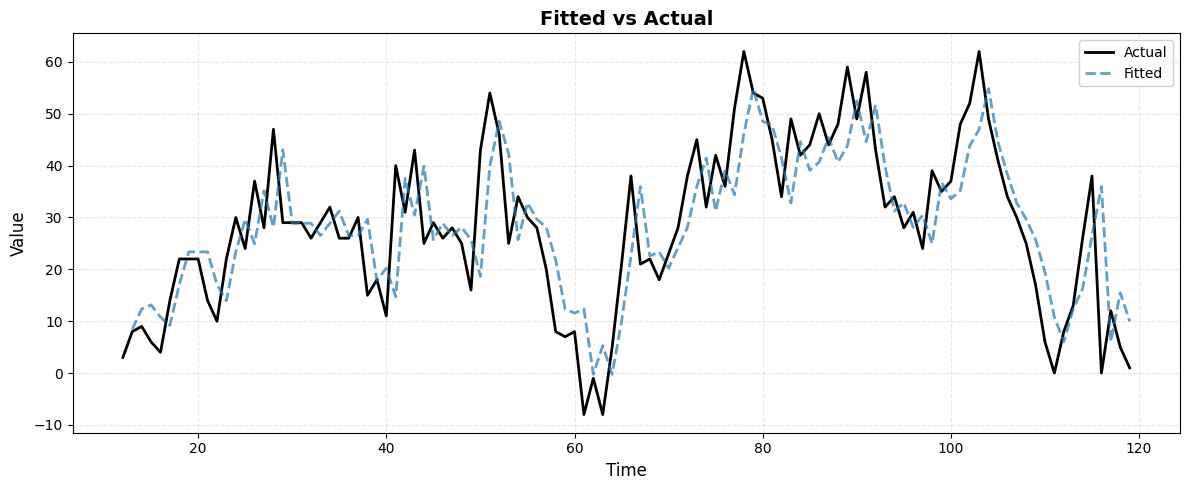

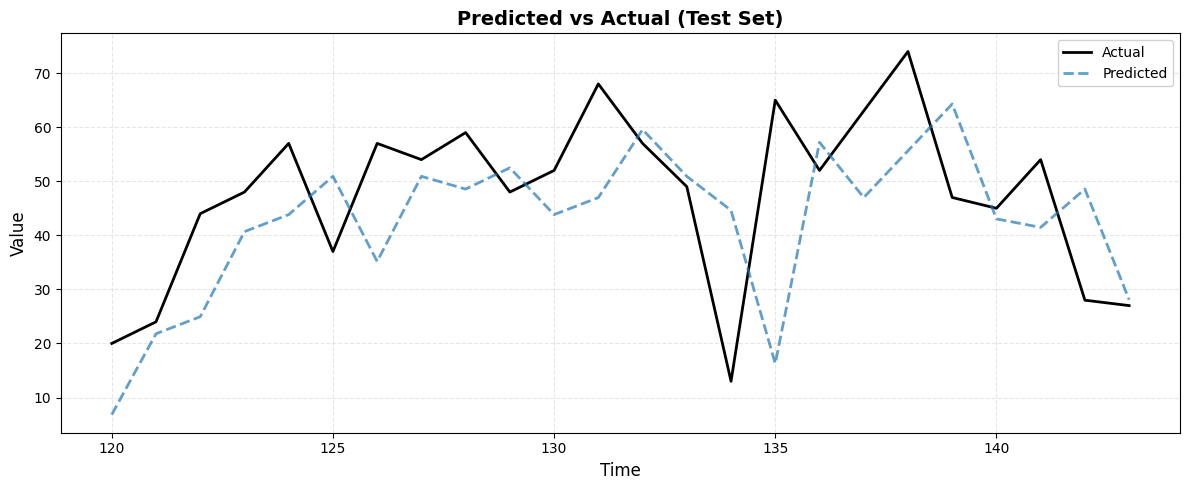

In [98]:
y_train_actuals = part_e_train["seasonal_differencing"]
y_test_actuals = part_e_test["seasonal_differencing"]

y_train_pred = seasonally_differenced_ar1.fittedvalues
y_test_pred = seasonally_differenced_ar1.predict(part_e_test)

r2 = seasonally_differenced_ar1.rsquared
osr2 = r2_score(y_test_actuals, y_test_pred)

print(f"R^2 for seasonally differenced:    {r2:.4f}")
print(f"OSR^2 for seasonally differenced: {osr2:.4f}")

plot_fitted_vs_actual(y_train_actuals, seasonally_differenced_ar1)
plot_predicted_vs_actual(y_test_actuals, y_test_pred)

The AR(1) model for seasonal differences shows a mixed performance:

**Good In-sample Fit**

It effectively models historical variation. The R-squared isn't bad, and visually it is
following the overall upswings and downswings of the differenced series well. 

**Poor Out-of-sample Predictive Power**

It fails to generalize to new unseen data – negative OSR^2. Visually, the model 
frequently misses the magnitude and timing of the peaks and troughs. Negative R-squared
also means that prediciting the mean would be better than this model. 

While an autoregressive component is present, a simple AR(1) structure is insufficient to
accurately forecast the future movements of the seasonally differenced passenger data. 